## Analysis of Results

Info about scenario ?

In [1]:
# Capacity demand (Implicit)
# Capacity demand = Peak demand - renewables generation during scarcity - imports during scarcity

#### Data extraction

In [2]:
# pip install pyyaml pandas numpy matplotlib scipy

In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Any, List
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


In [4]:
def read_inputs(base_dir: str | Path) -> Dict[str, Any]:
    base_dir = Path(base_dir)
    inp = base_dir / "Input"
    # Load parameters from YAML config
    with open(inp / "config.yaml", "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    H = int(data["General"]["nTimesteps"])

    # Load input files
    load = pd.read_csv(inp / "load.csv", sep=";")
    pv = pd.read_csv(inp / "pv.csv", sep=";")
    wind_on = pd.read_csv(inp / "wind_onshore.csv", sep=";")
    nptdf = pd.read_csv(inp / "nodal_ptdf.csv", sep=";")
    lines = pd.read_csv(inp / "lines.csv", sep=";")
    scarcity_df = pd.read_csv(inp / "scarcity.csv", sep=";")

    # load analysis data files


    # Load weights
    weights_path = inp / "timeseries.csv"
    if weights_path.is_file():
        df_w = pd.read_csv(weights_path, sep=";")
        W = df_w["weights"].astype(float).to_numpy()[:H] if "weights" in df_w else np.ones(H)
        if W.size < H:
            W = np.pad(W, (0, H - W.size), mode="constant", constant_values=1.0)
    else:
        W = np.ones(H)

    return {
        "data": data,
        "load": load,
        "pv": pv,
        "wind_on": wind_on,
        "nptdf": nptdf,
        "lines": lines,
        "weights": W,
        "scarcity": scarcity_df,
    }


if __name__ == "__main__":
    inputs = read_inputs(Path().resolve())
    print(inputs.keys())
print(inputs["load"][:5])


dict_keys(['data', 'load', 'pv', 'wind_on', 'nptdf', 'lines', 'weights', 'scarcity'])
        Unnamed: 0         A        B         C
0  20-3-2025 00:00  45730.25  8211.00  11471.75
1  20-3-2025 01:00  44302.50  7814.25  10987.75
2  20-3-2025 02:00  43733.50  7642.75  10642.75
3  20-3-2025 03:00  44037.75  7500.25  10545.25
4  20-3-2025 04:00  45518.25  7574.25  10644.00


In [5]:
# Load analysis data
def load_analysis_data(base_dir: str | Path) -> Dict[str, pd.DataFrame]:
    base_dir = Path(base_dir)
    analysis_dir = base_dir / "analysis_data"
    categories = ["eom", "explicit_FBMC", "explicit_NTC", "implicit", "pricecap", "NoCBP"]
    data = {}

    for category in categories:
        category_path = analysis_dir / category
        if category_path.is_dir():
            for file in category_path.glob("*.csv"):
                key = f"{file.stem}"
                data[key] = pd.read_csv(file, sep=";")
    return data

if __name__ == "__main__":
    analysis_data = load_analysis_data(Path().resolve())
    print(analysis_data.keys())
    
analysis_data["planner_zone_A_eom"][:5]

dict_keys(['mcp_zone_A_eom', 'mcp_zone_B_eom', 'mcp_zone_C_eom', 'planner_zone_A_eom', 'planner_zone_B_eom', 'planner_zone_C_eom', 'mcp_zone_A_FBMC', 'mcp_zone_B_FBMC', 'mcp_zone_C_FBMC', 'planner_zone_A_FBMC', 'planner_zone_B_FBMC', 'planner_zone_C_FBMC', 'mcp_zone_A_NTC', 'mcp_zone_B_NTC', 'mcp_zone_C_NTC', 'planner_zone_A_NTC', 'planner_zone_B_NTC', 'planner_zone_C_NTC', 'mcp_zone_A_implicit', 'mcp_zone_B_implicit', 'mcp_zone_C_implicit', 'planner_zone_A_implicit', 'planner_zone_B_implicit', 'planner_zone_C_implicit', 'mcp_zone_A_pricecap', 'mcp_zone_B_pricecap', 'mcp_zone_C_pricecap', 'planner_zone_A_pricecap', 'planner_zone_B_pricecap', 'planner_zone_C_pricecap', 'mcp_zone_A_NoCBP', 'mcp_zone_B_NoCBP', 'mcp_zone_C_NoCBP', 'planner_zone_A_NoCBP', 'planner_zone_B_NoCBP', 'planner_zone_C_NoCBP'])


,Timestep,EOM_price,Gen_A_Baseload,new_Capacity_Gen_A_Baseload,Capacity_Gen_A_Baseload,Gen_A_MidMerit,new_Capacity_Gen_A_MidMerit,Capacity_Gen_A_MidMerit,Gen_A_PV,new_Capacity_Gen_A_PV,...,new_Capacity_Gen_A_Peak,Capacity_Gen_A_Peak,Gen_A_WindOnshore,new_Capacity_Gen_A_WindOnshore,Capacity_Gen_A_WindOnshore,Cons_A,Inelastic_Cons_A,Elastic_Cons_A,NetworkManager,ENS_Cons_A
0,1.0,35.67,17668.19,26972.25,26972.25,0.0,7634.21,7634.21,0.0,0.0,...,8308.62,8308.62,22045.75,0.0,72618.0,45713.94,36584.2,9129.74,6000.0,0.0
1,2.0,35.41,17405.81,26972.25,26972.25,0.0,7634.21,7634.21,0.0,0.0,...,8308.62,8308.62,20881.00,0.0,72618.0,44286.81,35442.0,8844.81,6000.0,0.0
2,3.0,35.66,17655.66,26972.25,26972.25,0.0,7634.21,7634.21,0.0,0.0,...,8308.62,8308.62,20062.25,0.0,72618.0,43717.91,34986.8,8731.11,6000.0,0.0
3,4.0,36.43,18431.21,26972.25,26972.25,0.0,7634.21,7634.21,0.0,0.0,...,8308.62,8308.62,19590.50,0.0,72618.0,44021.71,35230.2,8791.51,6000.0,0.0
4,5.0,38.07,20067.92,26972.25,26972.25,0.0,7634.21,7634.21,0.0,0.0,...,8308.62,8308.62,19433.00,0.0,72618.0,45500.92,36414.6,9086.32,6000.0,0.0


#### Capacity plots

In [6]:
# select either "planner" or "mcp" data by changing the key construction below
def extract_total_planner_capacity(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]

    records = []
    for design_key in design_keys:
        for zone in zones:
            # Construct the key
            key = f"planner_zone_{zone}_{design_key}"
            if key not in data:
                print(f"Key not found: {key}")  # Debugging statement
                continue
            df = data[key]
            row = {"Zone": zone, "Design": design_key}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                row[g] = df[col].iloc[0] if col in df.columns else 0  # Use the first value
            records.append(row)

        # Add "Com" (combined)
        total = {"Zone": "Com", "Design": design_key}
        for g in gen_types:
            total[g] = sum(r[g] for r in records if r["Design"] == design_key)
        records.append(total)

    return pd.DataFrame(records)

In [7]:
installed_capacity_planner = extract_total_planner_capacity(analysis_data)
# print(installed_capacity)

# add a sum to the installed capacity dataframe
installed_capacity_planner_sum = installed_capacity_planner.copy()
installed_capacity_planner_sum['Total'] = installed_capacity_planner_sum[['Baseload', 'MidMerit', 'Peak']].sum(axis=1)
print(installed_capacity_planner_sum)

   Zone    Design  Baseload  MidMerit      Peak      Total
0     A       eom  26972.25   7634.21   8308.62   42915.08
1     B       eom   8301.50   1216.70   1255.32   10773.52
2     C       eom   9641.32   2221.66   1957.20   13820.18
3   Com       eom  44915.07  11072.57  11521.14   67508.78
4     A      FBMC  25278.78   5973.45  40547.29   71799.52
5     B      FBMC   9292.73   2541.64   1820.76   13655.13
6     C      FBMC   9648.20   2753.09   2299.03   14700.32
7   Com      FBMC  44219.71  11268.18  44667.08  100154.97
8     A       NTC  25275.36   5966.07  42007.22   73248.65
9     B       NTC   9291.11   2544.33   1821.10   13656.54
10    C       NTC   9652.99   2759.60   4073.06   16485.65
11  Com       NTC  44219.46  11270.00  47901.38  103390.84
12    A  implicit  25278.26   5972.34  33781.55   65032.15
13    B  implicit   9400.96   2606.63   1865.56   13873.15
14    C  implicit   9540.45   2689.57   2443.77   14673.79
15  Com  implicit  44219.67  11268.54  38090.88   93579.

In [8]:
# select either "planner" or "mcp" data by changing the key construction below
def extract_total_capacity(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]

    records = []
    for design_key in design_keys:
        for zone in zones:
            # Construct the key
            key = f"mcp_zone_{zone}_{design_key}"
            if key not in data:
                print(f"Key not found: {key}")  # Debugging statement
                continue
            df = data[key]
            row = {"Zone": zone, "Design": design_key}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                row[g] = df[col].iloc[0] if col in df.columns else 0  # Use the first value
            records.append(row)

        # Add "Com" (combined)
        total = {"Zone": "Com", "Design": design_key}
        for g in gen_types:
            total[g] = sum(r[g] for r in records if r["Design"] == design_key)
        records.append(total)

    return pd.DataFrame(records)

In [9]:
installed_capacity = extract_total_capacity(analysis_data)
# print(installed_capacity)

# add a sum to the installed capacity dataframe
installed_capacity_sum = installed_capacity.copy()
installed_capacity_sum['Total'] = installed_capacity_sum[['Baseload', 'MidMerit', 'Peak']].sum(axis=1)
print(installed_capacity_sum)

   Zone    Design      Baseload      MidMerit          Peak          Total
0     A       eom  27783.509609   9196.819688   8212.399186   45192.728484
1     B       eom   9407.357469    880.448549    124.740573   10412.546592
2     C       eom  10222.203543   1190.300327    181.868192   11594.372063
3   Com       eom  47413.070622  11267.568565   8519.007952   67199.647138
4     A      FBMC  25480.801779   6732.113975  40659.958560   72872.874314
5     B      FBMC  10755.184567   2674.953490    831.510959   14261.649015
6     C      FBMC  10120.180543   2227.619011    672.647117   13020.446671
7   Com      FBMC  46356.166889  11634.686476  42164.116636  100154.970000
8     A       NTC  25189.034188   6040.149866  42019.465945   73248.649999
9     B       NTC  10214.577454   2512.927589    867.352363   13594.857407
10    C       NTC  10872.319364   2970.219325   2704.783487   16547.322176
11  Com       NTC  46275.931007  11523.296780  45591.601795  103390.829582
12    A  implicit  25187.

In [10]:
def extract_capacity_changes(df: pd.DataFrame, ref_design="eom") -> pd.DataFrame:
    zones = ["A", "B", "C", "Com"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    deltas = []

    base_df = df[df["Design"] == ref_design]

    for design in df["Design"].unique():
        if design == ref_design:
            continue
        for zone in zones:
            base = base_df[(base_df["Zone"] == zone)]
            current = df[(df["Zone"] == zone) & (df["Design"] == design)]
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                base_val = base[g].values[0] if not base.empty else 0
                curr_val = current[g].values[0] if not current.empty else 0
                delta[g] = curr_val - base_val
            deltas.append(delta)

    return pd.DataFrame(deltas)

In [11]:
def plot_capacity_bars(df: pd.DataFrame, ylabel: str):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        design_start_pos = pos
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    bottom = np.zeros(len(x_labels))

    fig, ax = plt.subplots(figsize=(14, 6))
    for g in gen_types:
        ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
        bottom += np.array(data[g])

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(0, bottom.max() * 1.1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    
    # Add market design labels as text
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, design, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

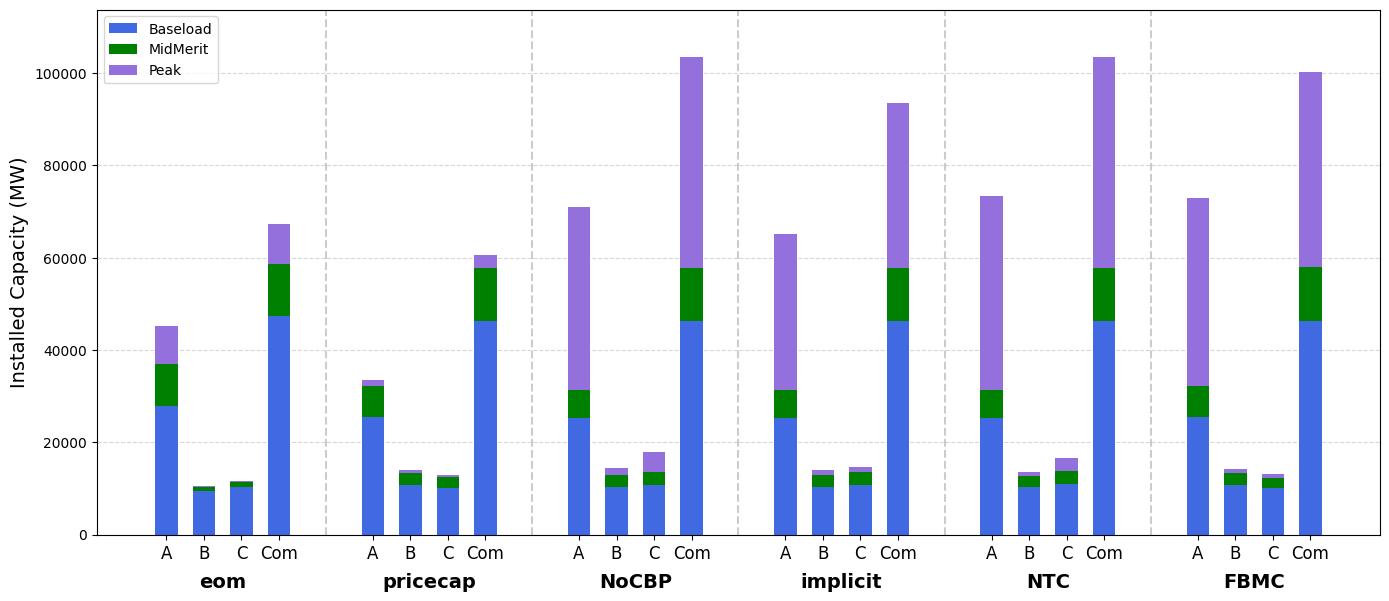

In [12]:
# Extract capacity data
capacity_data = extract_total_capacity(analysis_data)

# Plot total capacity
plot_capacity_bars(capacity_data, "Installed Capacity (MW)")


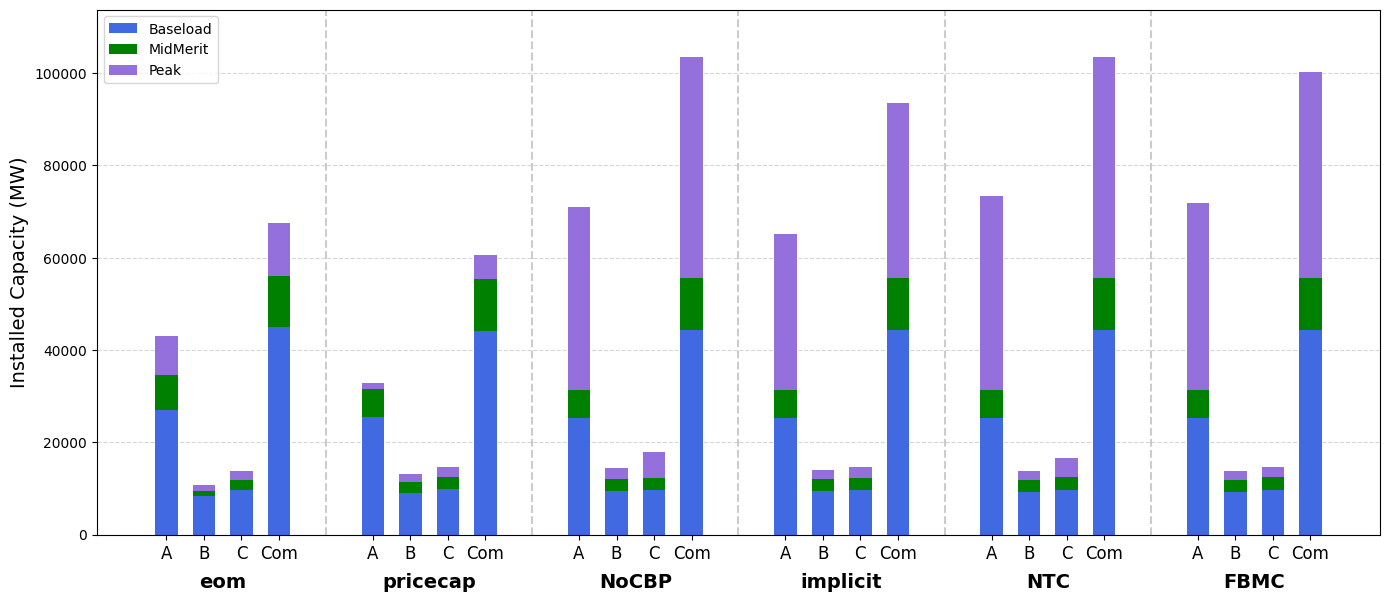

In [13]:
# Extract planner capacity data
planner_capacity_data = extract_total_planner_capacity(analysis_data)
plot_capacity_bars(planner_capacity_data, "Installed Capacity (MW)")

In [14]:
def extract_planner_mcp_diffs(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]
    
    deltas = []
    
    for design in design_keys:
        for zone in zones:
            planner_key = f"planner_zone_{zone}_{design}"
            mcp_key = f"mcp_zone_{zone}_{design}"
            
            if planner_key not in data or mcp_key not in data:
                print(f"Key not found: {planner_key} or {mcp_key}")
                continue
                
            planner_df = data[planner_key]
            mcp_df = data[mcp_key]
            
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                
                planner_val = planner_df[col].iloc[0] if col in planner_df.columns else 0
                mcp_val = mcp_df[col].iloc[0] if col in mcp_df.columns else 0

                delta[g] = mcp_val - planner_val

            deltas.append(delta)
    
    # Add "Com" (combined) for each design
    for design in design_keys:
        design_deltas = [d for d in deltas if d["Design"] == design]
        if not design_deltas:
            continue
            
        com_delta = {"Zone": "Com", "Design": design}
        for g in gen_types:
            com_delta[g] = sum(d[g] for d in design_deltas)
        deltas.append(com_delta)
    
    return pd.DataFrame(deltas)

In [15]:
def plot_cap_bars(df: pd.DataFrame, ylabel: str, allow_negatives=True):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Handle positive and negative values differently for proper stacking
    if allow_negatives:
        # For data with positive and negative values
        bottom_pos = np.zeros(len(x_labels))
        bottom_neg = np.zeros(len(x_labels))
        
        for g in gen_types:
            data_array = np.array(data[g])
            mask_pos = data_array >= 0
            mask_neg = data_array < 0
            
            # Plot positive values (stack upward)
            ax.bar(np.array(x_positions)[mask_pos], data_array[mask_pos], 
                  width, bottom=bottom_pos[mask_pos], color=colors[g], label=g if g not in ax.get_legend_handles_labels()[1] else "")
            bottom_pos[mask_pos] += data_array[mask_pos]
            
            # Plot negative values (stack downward)
            ax.bar(np.array(x_positions)[mask_neg], data_array[mask_neg], 
                  width, bottom=bottom_neg[mask_neg], color=colors[g])
            bottom_neg[mask_neg] += data_array[mask_neg]
        
        # Calculate proper y-axis limits to show both positive and negative values
        y_max = bottom_pos.max() * 1.1 if bottom_pos.max() > 0 else 1
        y_min = bottom_neg.min() * 1.1 if bottom_neg.min() < 0 else -1
        ax.set_ylim(y_min, y_max)
        
    else:
        # Original implementation for positive-only data
        bottom = np.zeros(len(x_labels))
        for g in gen_types:
            ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
            bottom += np.array(data[g])
        ax.set_ylim(0, bottom.max() * 1.1)

    # Add zero line if we have negative values
    if allow_negatives:
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    
    # Add market design labels as text (adjusted for new spacing)
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, design, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

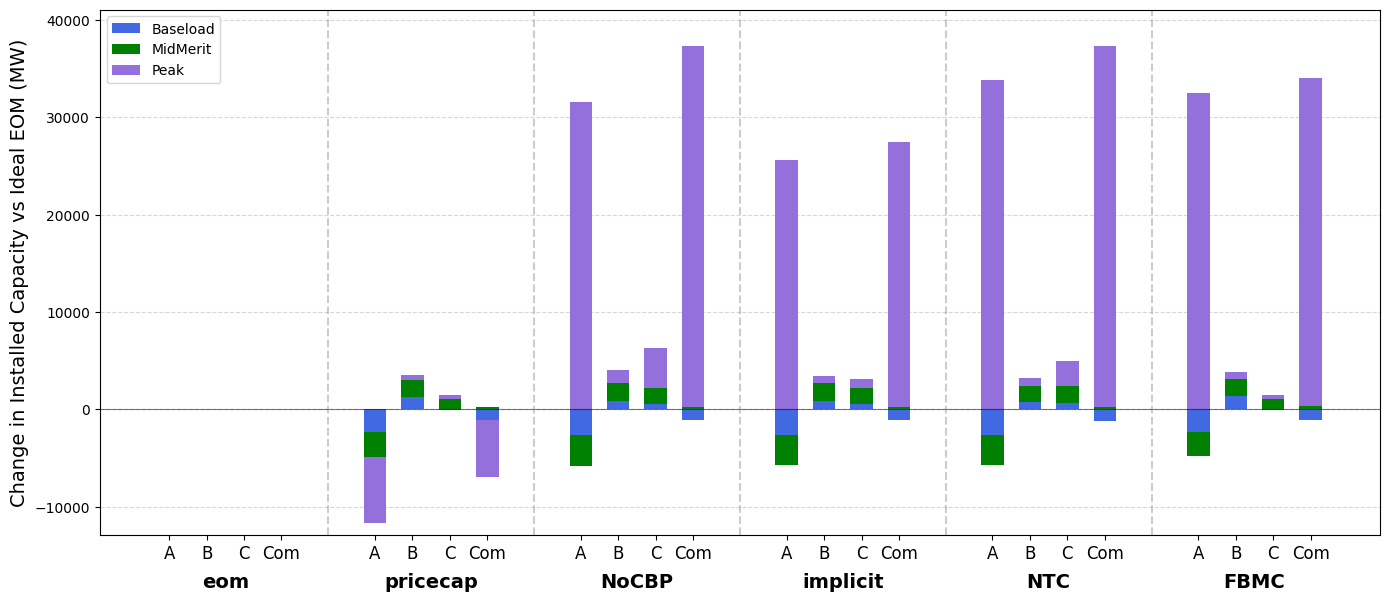

In [16]:
# plot capacity changes
capacity_changes = extract_capacity_changes(capacity_data)
plot_cap_bars(capacity_changes,"Change in Installed Capacity vs Ideal EOM (MW)")

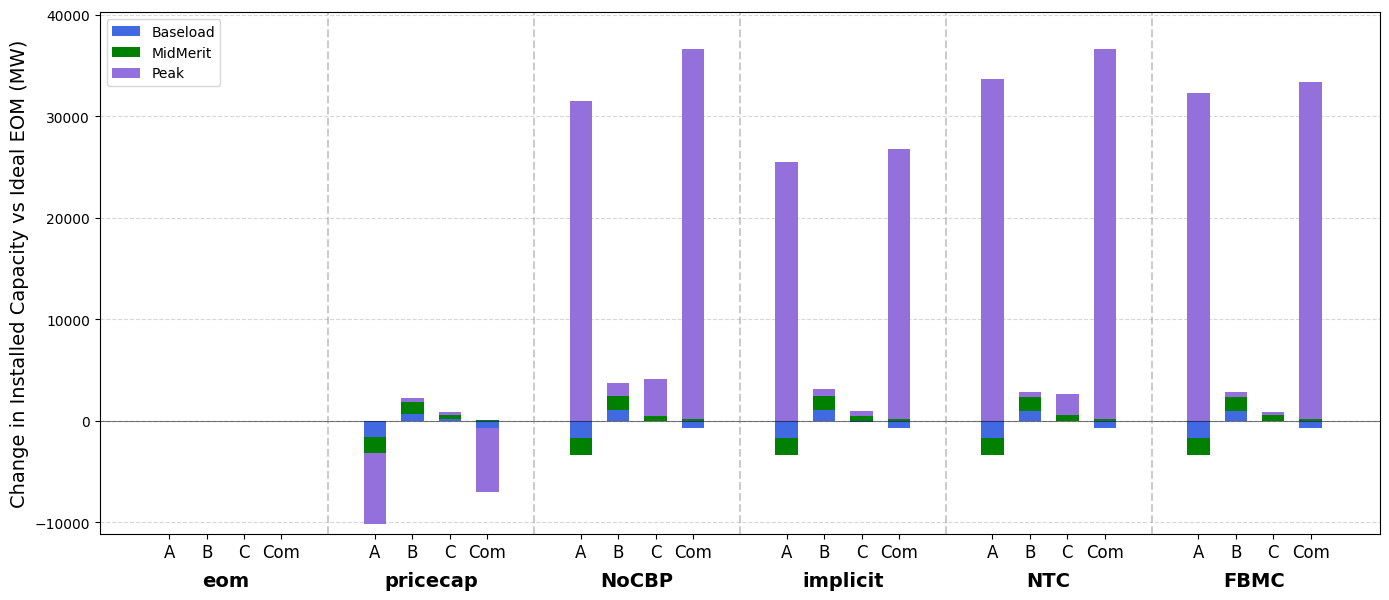

In [17]:
# plot capacity changes
planner_capacity_data = extract_capacity_changes(planner_capacity_data)
plot_cap_bars(planner_capacity_data, "Change in Installed Capacity vs Ideal EOM (MW)")

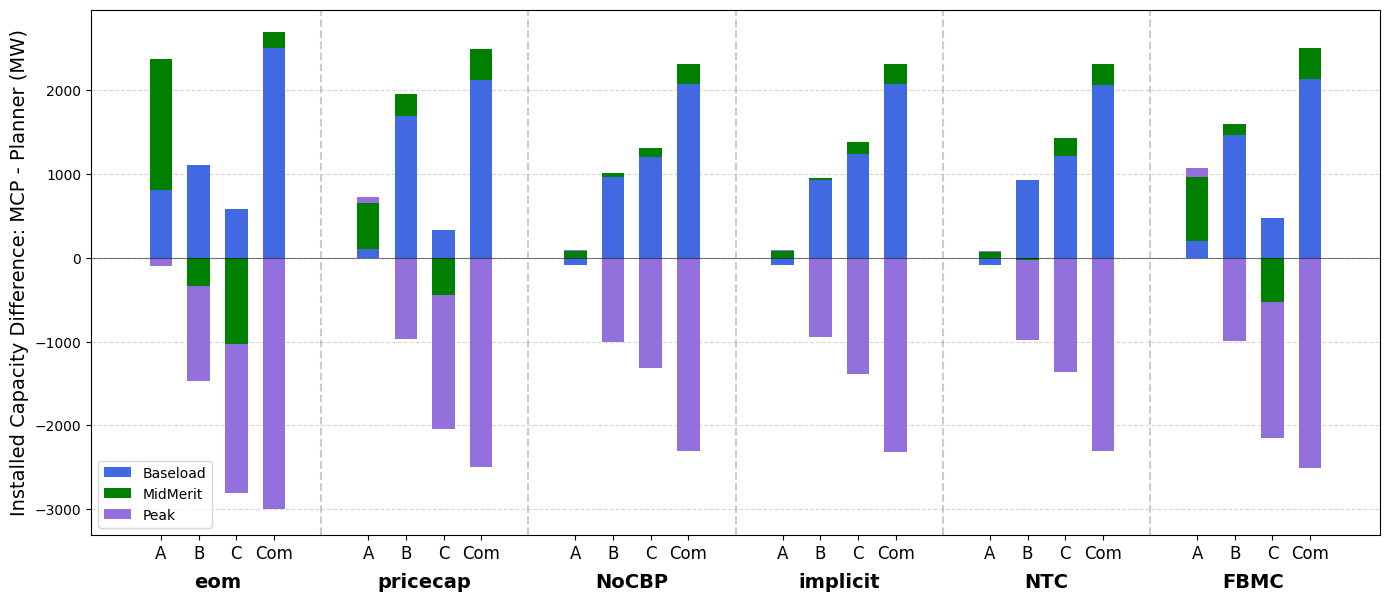

In [18]:
# Extract differences between planner and MCP models
planner_mcp_diffs = extract_planner_mcp_diffs(analysis_data)
plot_cap_bars(planner_mcp_diffs, "Installed Capacity Difference: MCP - Planner (MW)")

#### Merit order

In [19]:
def plot_merit_order_curve(
    analysis_data: dict,
    inputs: dict,
    hour: int,
    zone: str,
    market_design: str,
    source_type: str = "mcp"
):
    """
    Plot merit order curve showing generator offers, demand, and market clearing price.
    Properly handles quadratic cost curves: MC = a*g + b
    
    Parameters:
    - hour: timestep to analyze
    - zone: zone name (A, B, or C)
    - market_design: market design type (eom, FBMC, NTC, etc.)
    - source_type: "mcp" or "planner"
    """
    # Get the data key
    key = f"{source_type}_zone_{zone}_{market_design}"
    if key not in analysis_data:
        print(f"Error: {key} not found in analysis data")
        return
    
    df = analysis_data[key]
    hour = hour - 1
    # Get market clearing price and demand at this hour
    eom_price = df.at[hour, "EOM_price"]
    demand = abs(df.at[hour, f"Cons_{zone}"]) - df.at[hour, f"NetworkManager"]
    
    # Get generator parameters from config
    gen_types = ["WindOnshore", "PV", "Baseload", "MidMerit", "Peak"]
    gen_data = []
    
    for gen in gen_types:
        # Get ACTUAL GENERATION at this hour
        gen_col = f"Gen_{zone}_{gen}"
        generation = df.at[hour, gen_col] if gen_col in df.columns else 0
        
        if generation <= 0:
            continue
            
        # Get cost parameters from config
        if zone in inputs["data"]["Generators"] and gen in inputs["data"]["Generators"][zone]:
            gen_params = inputs["data"]["Generators"][zone][gen]
            a = gen_params.get("a", 0)  # Quadratic term
            b = gen_params.get("b", 0)  # Linear term (marginal cost at zero)
            
            # Get installed capacity
            capacity_col = f"Capacity_Gen_{zone}_{gen}"
            capacity = df.at[hour, capacity_col] if capacity_col in df.columns else 0
            
            gen_data.append({
                "Generator": gen,
                "Generation": generation,
                "Capacity": capacity,
                "a": a,
                "b": b
            })
    
    # Sort generators by their STARTING marginal cost (MC at g=0)
    gen_data = sorted(gen_data, key=lambda x: x["b"])
    
    # Build supply curve accounting for quadratic costs
    cumulative_generation = 0
    x_supply = [0]
    y_supply = [0]
    
    # Check if Peak generator is at capacity (for scarcity pricing)
    peak_at_capacity = False
    for gen in gen_data:
        if gen["Generator"] == "Peak" and gen["Capacity"] > 0:
            # Check if peak is producing at or near capacity (within 1% tolerance)
            if gen["Generation"] >= gen["Capacity"] * 0.99:
                peak_at_capacity = True
                break
    
    for gen in gen_data:
        # Starting point: cumulative generation before this generator
        x_start = cumulative_generation
        # Ending point: cumulative generation after this generator
        x_end = cumulative_generation + gen["Generation"]
        

        mc_start = gen["b"]
        # MC at end of this generator (g=generation for this generator): MC = a*generation + b
        mc_end = gen["a"] * gen["Generation"] + gen["b"]
        
        # Add both start and end points for smooth curve
        x_supply.append(x_start)
        y_supply.append(mc_start)
        x_supply.append(x_end)
        y_supply.append(mc_end)
        
        cumulative_generation = x_end
    
    # Add vertical scarcity line if Peak generator is at capacity
    if peak_at_capacity:
        # Add vertical line from last marginal cost to market clearing price
        x_supply.append(cumulative_generation)
        y_supply.append(eom_price)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot supply curve (merit order) - use default line style for smooth quadratic segments
    ax.plot(x_supply, y_supply, 'b-', linewidth=2, label='Supply Curve (Merit Order)')
    
    
    # Determine x-axis limit to ensure demand line is visible
    max_x = max(cumulative_generation, demand) * 1.1
    
    # Plot demand as vertical line
    ax.axvline(x=demand, color='red', linestyle='--', linewidth=2.5, 
               label=f'Demand ({demand:.0f} MW)', zorder=3)
    
    # Plot market clearing price as horizontal line
    max_price = max(max(y_supply) if y_supply else 0, eom_price) * 1.1
    ax.axhline(y=eom_price, color='green', linestyle='--', linewidth=2.5, 
               label=f'Market Clearing Price ({eom_price:.2f} €/MWh)', zorder=3)
    
    # Mark intersection point (where supply meets demand)
    ax.plot(demand, eom_price, 'ko', markersize=10, label='Market Equilibrium', zorder=5)
    
    # # Add shaded area for consumer surplus
    # if demand <= cumulative_generation and eom_price > 0:
    #     ax.fill_betweenx([0, eom_price], 0, demand, alpha=0.2, color='green', 
    #                      label='Consumer Surplus')
    
    # Formatting
    ax.set_xlabel('Generation / Demand (MW)', fontsize=13)
    ax.set_ylabel('Price (€/MWh)', fontsize=13)
    ax.set_title(f'Merit Order Curve - Zone {zone}, Hour {hour+1}, {market_design.upper()}', 
                 fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    # Set axis limits
    ax.set_xlim(0, max_x)
    ax.set_ylim(0, max_price)
    
    # Add generator labels on the supply curve
    cumulative = 0
    for gen in gen_data:
        mid_point = cumulative + gen["Generation"] / 2
        # Calculate marginal cost at midpoint for label placement
        # MC at midpoint of THIS generator's output
        g_mid = gen["Generation"] / 2
        mc_mid = gen["a"] * g_mid + gen["b"]
        y_pos = mc_mid + max_price * 0.02
        
        # Don't place labels too high if there's scarcity pricing
        if y_pos > max_price * 0.9:
            y_pos = mc_mid - max_price * 0.02
            
        ax.text(mid_point, y_pos, 
                gen["Generator"], 
                ha='center', va='bottom', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        cumulative += gen["Generation"]
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n--- Merit Order Summary ---")
    print(f"Zone: {zone} | Hour: {hour+1} | Design: {market_design}")
    print(f"Demand: {demand:.2f} MW")
    print(f"Total Generation: {cumulative_generation:.2f} MW")
    print(f"Market Clearing Price: {eom_price:.2f} €/MWh")
    print(f"Peak at Capacity: {'Yes' if peak_at_capacity else 'No'}")
    print(f"\nGenerator Stack (sorted by starting marginal cost):")
    cumulative = 0
    for gen in gen_data:
        # CORRECTED: Use individual generator output for MC calculation
        mc_start = gen["b"]
        mc_end = gen["a"] * gen["Generation"] + gen["b"]
        
        cumulative += gen["Generation"]
        utilization = (gen["Generation"] / gen["Capacity"] * 100) if gen["Capacity"] > 0 else 0
        print(f"  {gen['Generator']:12s}: {gen['Generation']:8.2f} MW (Cap: {gen['Capacity']:8.2f} MW, {utilization:5.1f}%) | "
              f"MC: {mc_start:6.2f} → {mc_end:6.2f} €/MWh | "
              f"Cumulative: {cumulative:.2f} MW")
    
    return fig, ax

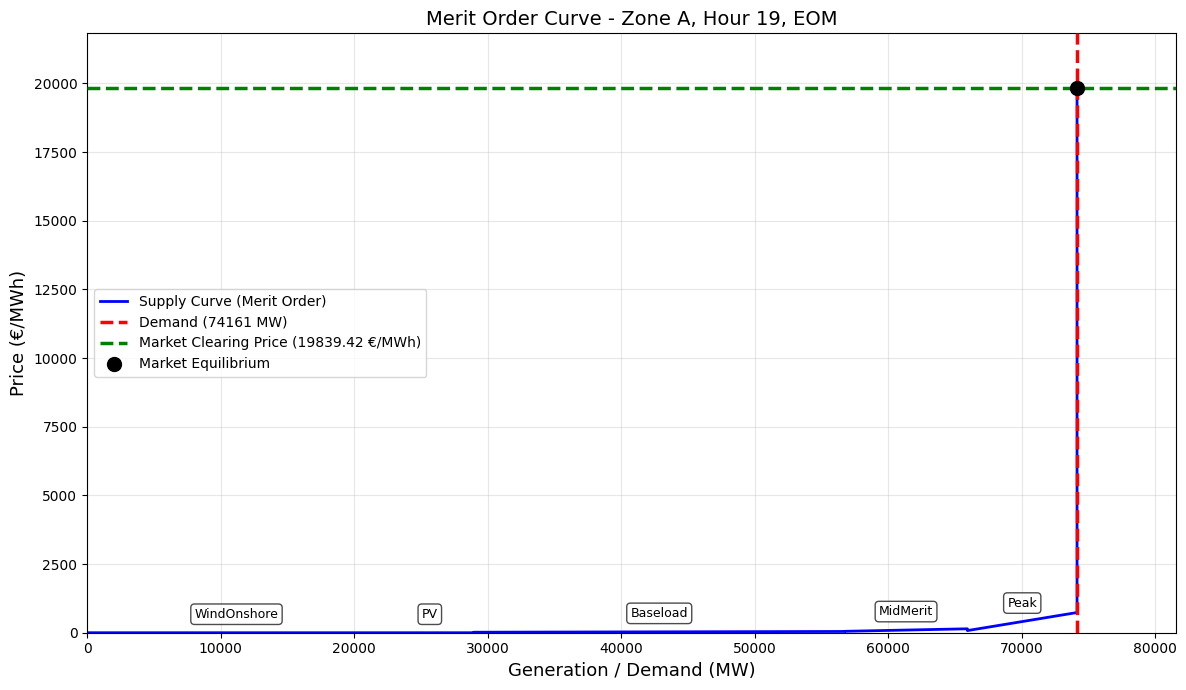


--- Merit Order Summary ---
Zone: A | Hour: 19 | Design: eom
Demand: 74160.58 MW
Total Generation: 74160.58 MW
Market Clearing Price: 19839.42 €/MWh
Peak at Capacity: Yes

Generator Stack (sorted by starting marginal cost):
  WindOnshore : 22374.35 MW (Cap: 72618.00 MW,  30.8%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 22374.35 MW
  PV          :  6593.50 MW (Cap: 86952.00 MW,   7.6%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 28967.85 MW
  Baseload    : 27783.51 MW (Cap: 27783.51 MW, 100.0%) | MC:  18.00 →  45.78 €/MWh | Cumulative: 56751.36 MW
  MidMerit    :  9196.82 MW (Cap:  9196.82 MW, 100.0%) | MC:  51.00 → 142.97 €/MWh | Cumulative: 65948.18 MW
  Peak        :  8212.40 MW (Cap:  8212.40 MW, 100.0%) | MC:  78.00 → 734.99 €/MWh | Cumulative: 74160.58 MW


In [20]:
# MCP merit order curve
fig, ax = plot_merit_order_curve(
    analysis_data=analysis_data,
    inputs=inputs,
    hour=19,  # Hour with high scarcity price
    zone="A",
    market_design="eom",
    source_type="mcp"
)

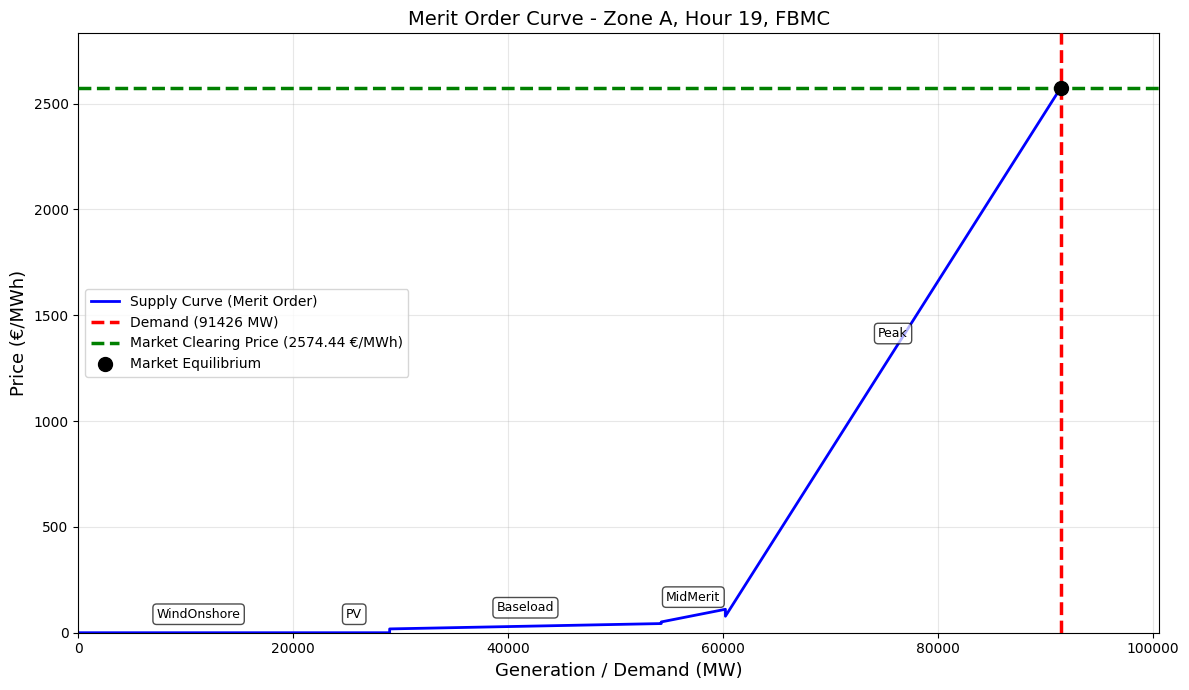


--- Merit Order Summary ---
Zone: A | Hour: 19 | Design: FBMC
Demand: 91425.56 MW
Total Generation: 91425.56 MW
Market Clearing Price: 2574.44 €/MWh
Peak at Capacity: No

Generator Stack (sorted by starting marginal cost):
  WindOnshore : 22374.35 MW (Cap: 72618.00 MW,  30.8%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 22374.35 MW
  PV          :  6593.50 MW (Cap: 86952.00 MW,   7.6%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 28967.85 MW
  Baseload    : 25278.78 MW (Cap: 25278.78 MW, 100.0%) | MC:  18.00 →  43.28 €/MWh | Cumulative: 54246.63 MW
  MidMerit    :  5973.45 MW (Cap:  5973.45 MW, 100.0%) | MC:  51.00 → 110.73 €/MWh | Cumulative: 60220.08 MW
  Peak        : 31205.48 MW (Cap: 40547.29 MW,  77.0%) | MC:  78.00 → 2574.44 €/MWh | Cumulative: 91425.56 MW


In [21]:
# planner merit order curve
fig, ax = plot_merit_order_curve(
    analysis_data=analysis_data,
    inputs=inputs,
    hour=19,  # Hour with high scarcity price
    zone="A",
    market_design="FBMC",
    source_type="planner"
)

#### Network flows

In [22]:
def plot_net_positions(data: Dict[str, pd.DataFrame], source_type: str = "planner"):
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    colors = {"import": "#C0C0C0", "export": "#9370DB"}
    bar_width = 0.7  # Wider single bar

    fig, ax = plt.subplots(figsize=(14, 7))

    # Set positions for bars (one position per zone per design)
    n_designs = len(design_keys)
    n_zones = len(zones)
    total_groups = n_designs * n_zones
    indices = np.arange(total_groups)

    imports = []
    exports = []

    # Build grouped data
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            net_import = 0
            net_export = 0

            if key in data and "NetworkManager" in data[key].columns:
                flows = data[key]["NetworkManager"].values
                net_import = flows[flows >= 0].sum()
                net_export = abs(flows[flows < 0].sum())  # Make exports positive for plotting

            imports.append(net_import)
            exports.append(-net_export)  # Store as negative for plotting below x-axis

    # Plotting both imports and exports in one bar
    ax.bar(indices, imports, bar_width, label="Net import", color=colors["import"])
    ax.bar(indices, exports, bar_width, label="Net export", color=colors["export"])

    # Annotate values on bars
    # for idx, (imp, exp) in enumerate(zip(imports, exports)):
    #     if imp > 0:
    #         ax.text(idx, imp/2, f"{abs(imp):.1f}", ha='center', va='top', fontsize=9)
    #     if exp < 0:
    #         ax.text(idx, exp/2, f"{abs(exp):.1f}", ha='center', va='bottom', fontsize=9)

    # Add vertical design group labels
    for i, design in enumerate(design_keys):
        center = i * len(zones) + 1  # Middle of each group
        max_val = max([max(imports), abs(min(exports))]) if imports or exports else 1
        ax.text(center, max_val + 2.5, design, ha='center', va='bottom', fontsize=14)

    # Gridlines and axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Energy flows [MWh]", fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Set x-ticks as zone names within each design
    ax.set_xticks(indices)
    ax.set_xticklabels(zones * len(design_keys))

    # Add vertical lines between groups
    for i in range(1, n_designs):
        ax.axvline(i * n_zones - 0.5, color='gray', linestyle='--', alpha=0.6)

    ax.legend(loc='upper left')
    
    # Set symmetric y-limits for better visual comparison
    y_limit = max(max(imports), abs(min(exports))) * 1.1
    ax.set_ylim(-y_limit, y_limit)
    
    plt.tight_layout()

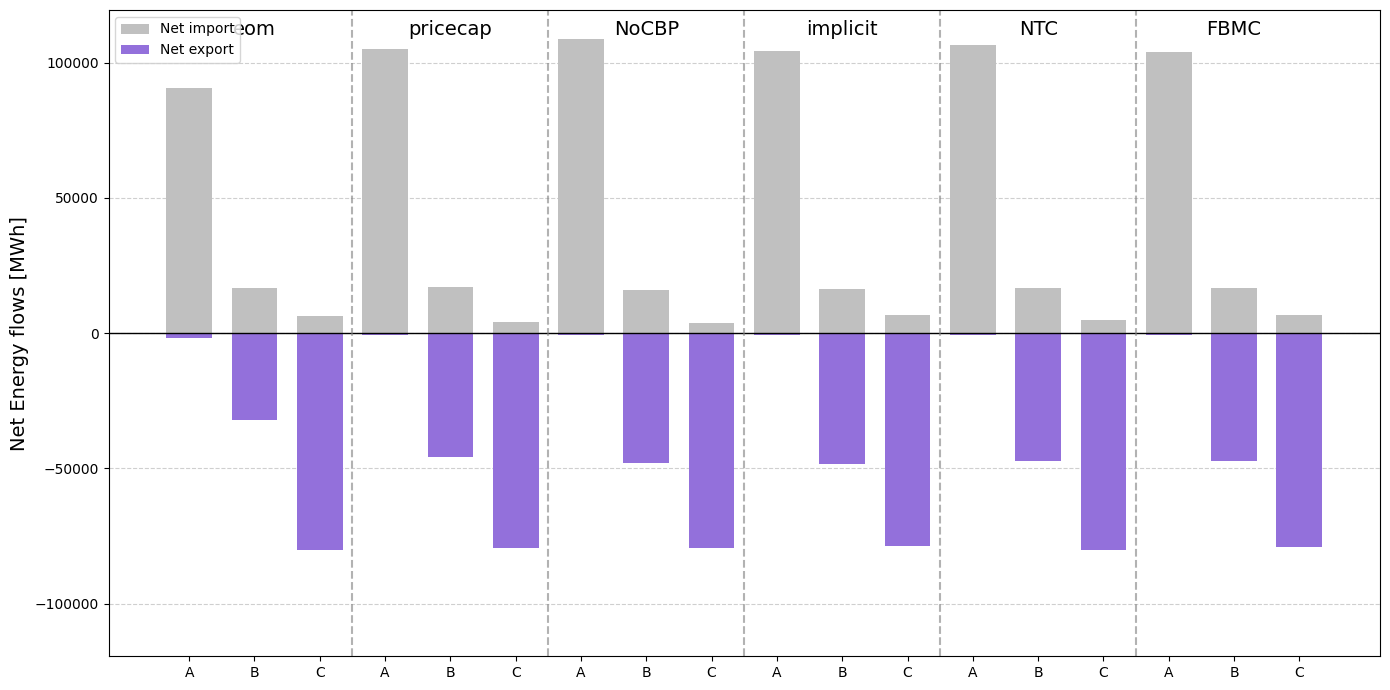

In [23]:
# Visualize net positions by zone
plot_net_positions(analysis_data, source_type="planner")

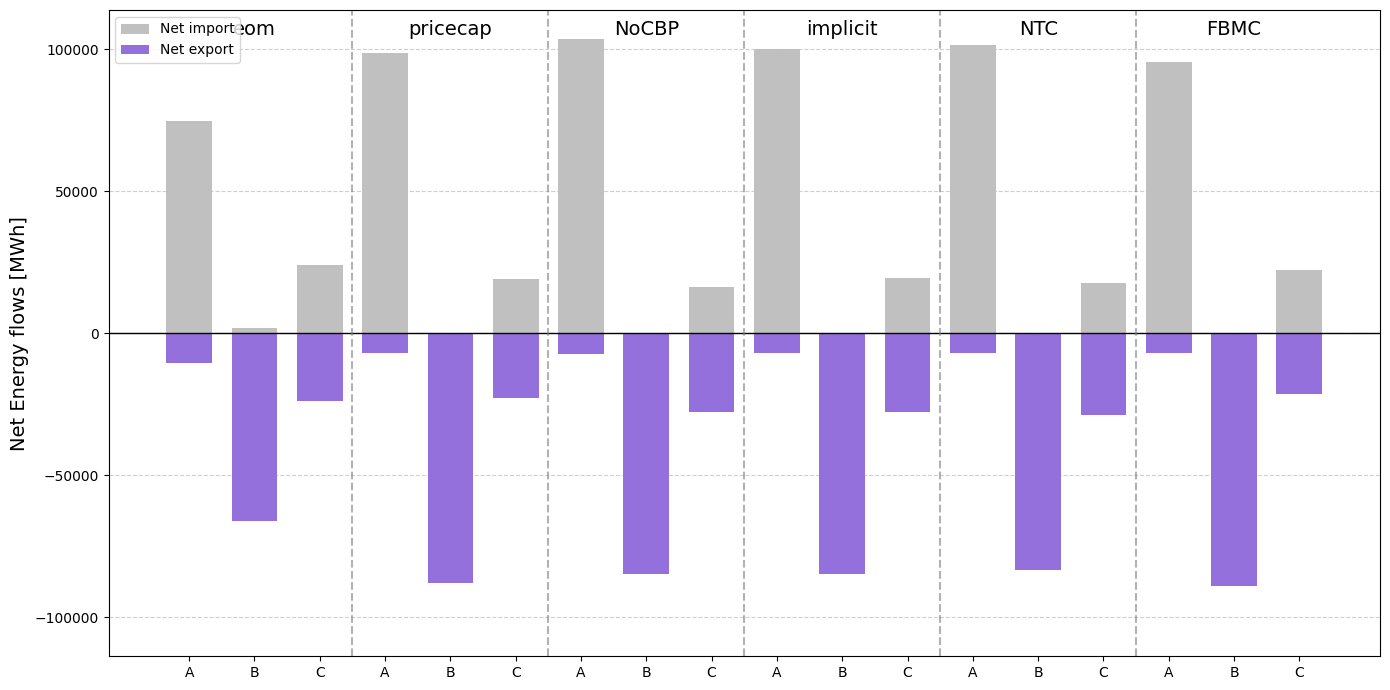

In [24]:
plot_net_positions(analysis_data, source_type="mcp")

In [25]:
# Congestion Rent
# implicit:
# zone A :
# zone B :
# zone C :


# ATC:
# zone A :
# zone B :
# zone C :

# FBMC:
# zone A :
# zone B :
# zone C :


In [26]:
def plot_capacity_net_positions(data: Dict[str, pd.DataFrame], source_type: str = "planner"):
    """
    Plot net capacity positions (CapacityManager) for FBMC and NTC designs only.
    Uses the same color scheme as plot_net_positions.
    """
    zones = ["A", "B", "C"]
    design_keys = ["NTC", "FBMC"]  # Only explicit capacity market designs
    colors = {"import": "#C0C0C0", "export": "#9370DB"}
    bar_width = 0.7

    fig, ax = plt.subplots(figsize=(14, 7))

    # Set positions for bars (one position per zone per design)
    n_designs = len(design_keys)
    n_zones = len(zones)
    total_groups = n_designs * n_zones
    indices = np.arange(total_groups)

    imports = []
    exports = []

    # Build grouped data
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            net_import = 0
            net_export = 0

            if key in data and "CapacityManager" in data[key].columns:
                # CapacityManager contains capacity trade flows - take only first value
                flows = data[key]["CapacityManager"].iloc[0]
                net_import = flows if flows >= 0 else 0
                net_export = abs(flows) if flows < 0 else 0

            imports.append(net_import)
            exports.append(-net_export)  # Store as negative for plotting below x-axis

    # Plotting both imports and exports
    ax.bar(indices, imports, bar_width, label="Capacity import", color=colors["import"])
    ax.bar(indices, exports, bar_width, label="Capacity export", color=colors["export"])

    # Add value labels on bars
    for idx, (imp, exp) in enumerate(zip(imports, exports)):
        if imp > 0:
            ax.text(idx, imp + max(imports) * 0.02, f"{abs(imp):.0f}", 
                   ha='center', va='bottom', fontsize=9)
        if exp < 0:
            ax.text(idx, exp - abs(min(exports)) * 0.02, f"{abs(exp):.0f}", 
                   ha='center', va='top', fontsize=9)

    # Add vertical design group labels
    for i, design in enumerate(design_keys):
        center = i * len(zones) + 1  # Middle of each group
        max_val = max([max(imports), abs(min(exports))]) if imports or exports else 1
        ax.text(center, max_val * 1.15, design, ha='center', va='bottom', fontsize=14, fontweight='bold')

    # Gridlines and axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Capacity Trade [MW]", fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Set x-ticks as zone names within each design
    ax.set_xticks(indices)
    ax.set_xticklabels(zones * len(design_keys), fontsize=12)

    # Add vertical lines between groups
    for i in range(1, n_designs):
        ax.axvline(i * n_zones - 0.5, color='gray', linestyle='--', alpha=0.6)

    ax.legend(loc='upper left', fontsize=11)
    
    # Set symmetric y-limits for better visual comparison
    if imports or exports:
        y_limit = max(max(imports), abs(min(exports))) * 1.3
    else:
        y_limit = 100
    ax.set_ylim(-y_limit, y_limit)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Make room for design labels
    return fig, ax


=== MCP Capacity Trade (FBMC & NTC) ===


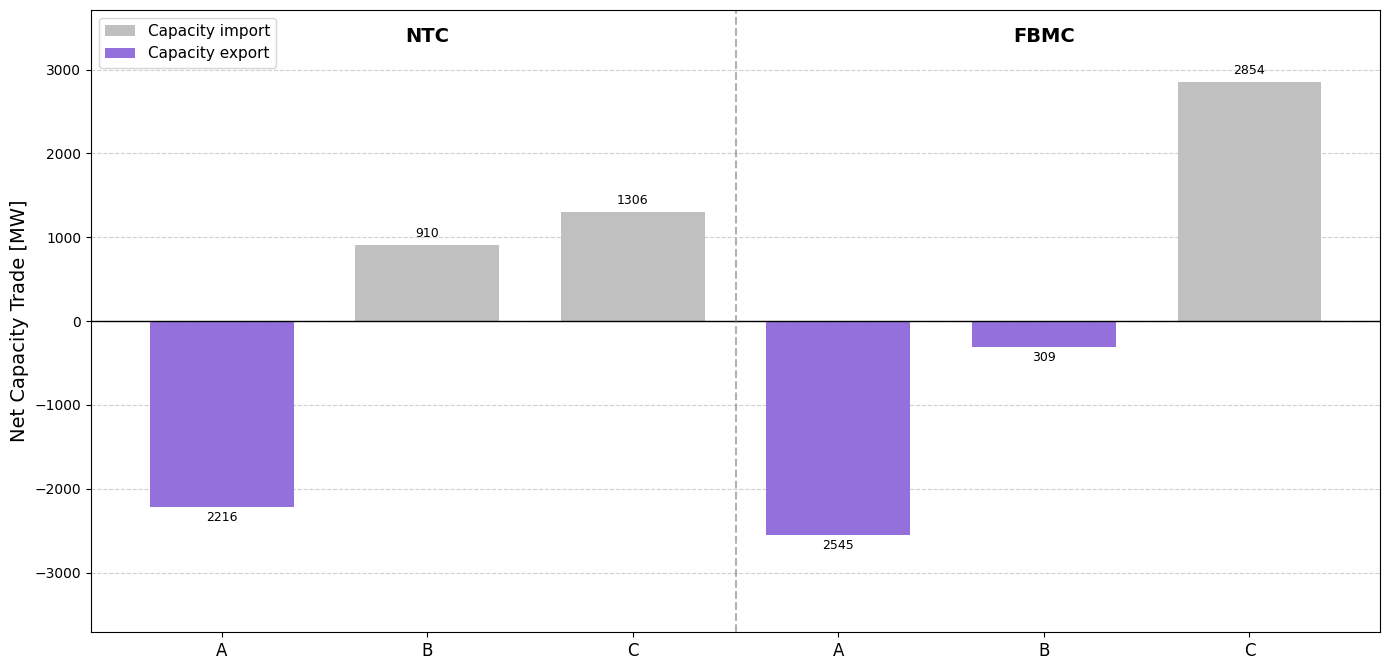

In [27]:
# Visualize capacity net positions for MCP model
print("\n=== MCP Capacity Trade (FBMC & NTC) ===")
fig, ax = plot_capacity_net_positions(analysis_data, source_type="mcp")
plt.show()

=== Planner Capacity Trade (FBMC & NTC) ===


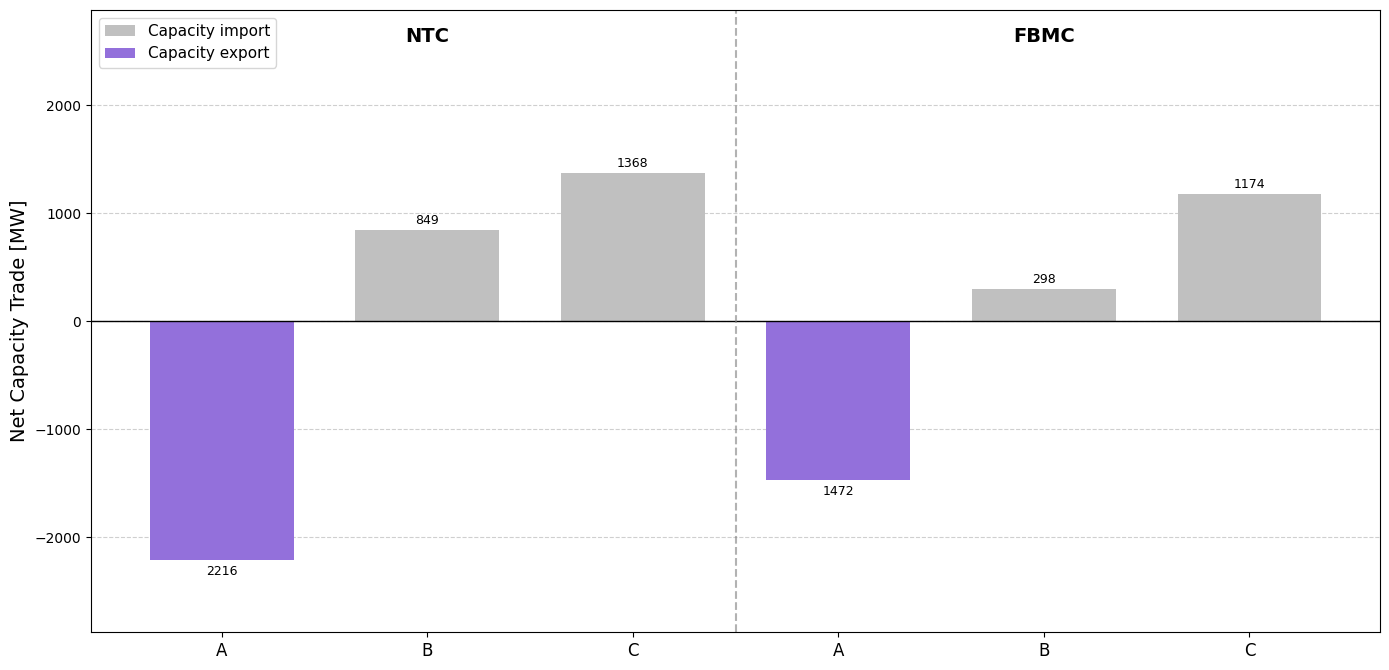

In [28]:
# Visualize capacity net positions for Planner model
print("=== Planner Capacity Trade (FBMC & NTC) ===")
fig, ax = plot_capacity_net_positions(analysis_data, source_type="planner")
plt.show()


#### Demand Analysis

In [29]:
def residual_demand(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, np.ndarray]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    load_df = inputs["load"]
    
    # Process each design and zone
    for design in design_keys:
        for zone in zones:
            
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                # Get the load for this zone from the INPUT load.csv file
                zone_load = load_df[zone].values if zone in load_df.columns else np.zeros(len(load_df))
                # print(zone_load)
                # Calculate renewable generation for this zone from results
                wind_col = f"Gen_{zone}_WindOnshore"
                pv_col = f"Gen_{zone}_PV"
                
                # Check if renewable generation columns exist
                wind = data[key][wind_col].values if wind_col in data[key].columns else np.zeros_like(zone_load)
                pv = data[key][pv_col].values if pv_col in data[key].columns else np.zeros_like(zone_load)
                
                # Calculate residual load at time step
                total_ren_gen = wind + pv
                result[design][zone] = np.maximum(zone_load - total_ren_gen, 0.0)
    
    return result

In [30]:
def plot_residual_load(residual_loads: Dict[str, Dict[str, np.ndarray]], design: str = "eom"):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Define custom zone colors
    zone_colors = {
        "A": "royalblue", 
        "B": "green", 
        "C": "mediumpurple"
    }
    
    # Get weights for proper duration curve
    W = inputs["weights"]
    
    for zone in ["A", "B", "C"]:
        if residual_loads[design][zone] is not None:
            loads = residual_loads[design][zone]
            weights = W[:len(loads)]
            
            # Apply weights to create weighted duration curve
            # Sort load values in descending order along with their weights
            sorted_indices = np.argsort(loads)[::-1]
            sorted_loads = loads[sorted_indices]
            sorted_weights = weights[sorted_indices]
            
            # Calculate cumulative weights for x-axis percentages
            cumulative_weights = np.cumsum(sorted_weights)
            percent_duration = 100.0 * cumulative_weights / cumulative_weights[-1]
            
            # Plot the weighted duration curve
            ax.plot(percent_duration, sorted_loads, label=f"Zone {zone}", 
                    color=zone_colors[zone], linewidth=3)
    
    # Add zero line for better visualization
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel("Duration (%)", fontsize=14)
    ax.set_ylabel("Residual Load (MW)", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

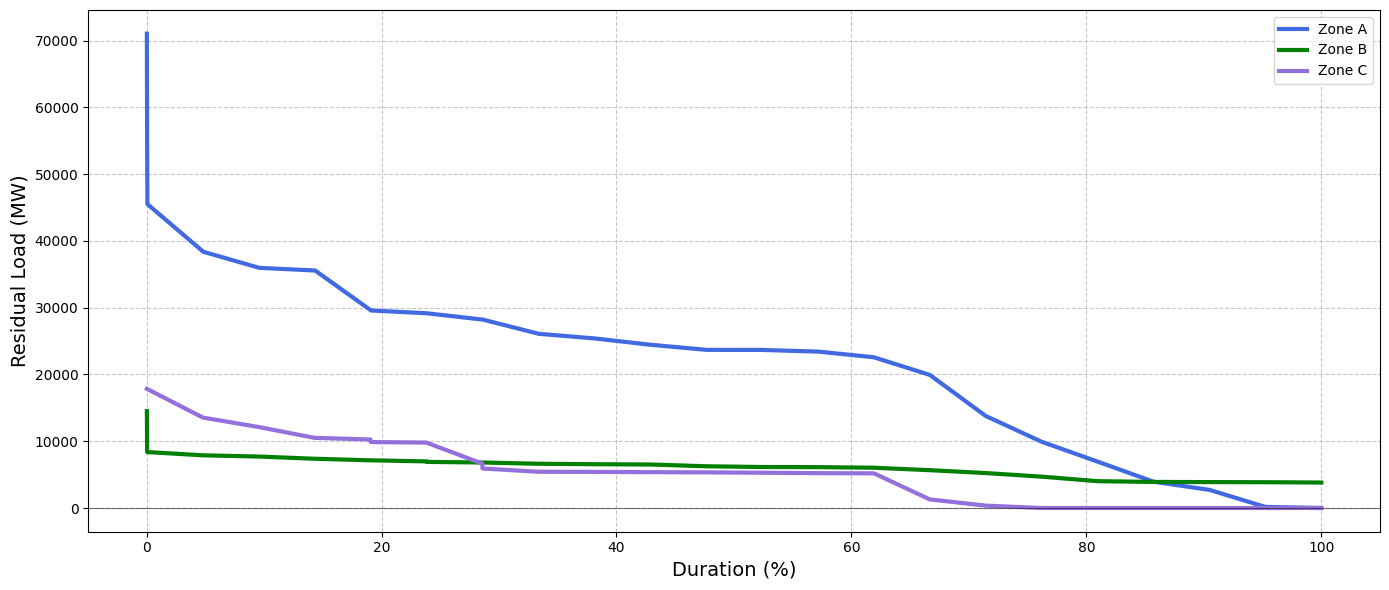

In [31]:
# Calculate residual loads if not already done
res_loads = residual_demand(analysis_data, source_type="planner")
# Plot for different designs
plot_residual_load(res_loads, design="eom")
# plot_residual_load(res_loads, design="pricecap")

In [32]:

# Calculate capacity demand for each zone using peak load from load.csv
# Capacity demand = Peak demand + ENS - renewable generation during peak - imports during peak
# Using FBMC to obtain capacity demand for implicit capacity demand estimation.

def capacity_demand(analysis_data: Dict[str, pd.DataFrame]):
    zones = ["A", "B", "C"]
    load_df = inputs["load"]

    for design in ["FBMC"]:  # Just check one design type
        for zone in zones:
            # Get peak load from original load CSV
            if zone not in load_df.columns:
                print(f"Warning: Zone {zone} not found in load data")
                continue
                
            peak_load_csv = load_df[zone].max()
            peak_hour_csv = load_df[zone].idxmax()
            
            key = f"planner_zone_{zone}_{design}"
            
            if key not in analysis_data:
                print(f"Warning: {key} not found in analysis data")
                continue
                
            # Get consumption data
            cons_col = f"Cons_{zone}"
            if cons_col not in analysis_data[key].columns:
                print(f"Warning: {cons_col} not found in {key}")
                continue
                
            # Find the peak consumption index in the analysis data
            peak_index = analysis_data[key][cons_col].idxmax()
            
            # Get ENS at peak time
            ens_col = f"ENS_Cons_{zone}"
            ens = abs(analysis_data[key].at[peak_index, ens_col]) if ens_col in analysis_data[key].columns else 0
            
            # Adjust peak load for ENS
            peak_load_total = peak_load_csv # + ens
            
            # Get renewable generation at peak load time
            wind_col = f"Gen_{zone}_WindOnshore"
            pv_col = f"Gen_{zone}_PV"
            
            wind_gen = analysis_data[key].at[peak_index, wind_col] if wind_col in analysis_data[key].columns else 0
            pv_gen = analysis_data[key].at[peak_index, pv_col] if pv_col in analysis_data[key].columns else 0
            total_ren_gen = wind_gen + pv_gen
            
            # Get network position (imports/exports)
            network_manager_col = "NetworkManager"
            net_pos = analysis_data[key].at[peak_index, network_manager_col] if network_manager_col in analysis_data[key].columns else 0
            
            # Calculate residual peak demand
            residual_peak = peak_load_total - total_ren_gen  # Implicit capacity demand
            implicit = residual_peak - net_pos  # Adjust for imports during scarcity (positive = import)
            
            # Print results
            print(f"Zone {zone}:")
            print(f"  Peak load (from CSV): {peak_load_csv:.2f} MW")
            print(f"  ENS at peak: {ens:.2f} MW")
            print(f"  Total peak load (incl. ENS): {peak_load_total:.2f} MW")
            print(f"  Renewable generation during peak: {total_ren_gen:.2f} MW")
            print(f"  Capacity demand (explicit): {residual_peak:.2f} MW")
            print(f"  Net import during scarcity: {net_pos:.2f} MW")
            print(f"  Capacity demand (implicit): {implicit:.2f} MW")
            print()

# Call the function
capacity_demand(analysis_data)

Zone A:
  Peak load (from CSV): 100000.00 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 100000.00 MW
  Renewable generation during peak: 28967.85 MW
  Capacity demand (explicit): 71032.15 MW
  Net import during scarcity: 6000.00 MW
  Capacity demand (implicit): 65032.15 MW

Zone B:
  Peak load (from CSV): 15000.00 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 15000.00 MW
  Renewable generation during peak: 494.86 MW
  Capacity demand (explicit): 14505.14 MW
  Net import during scarcity: 629.21 MW
  Capacity demand (implicit): 13875.93 MW

Zone C:
  Peak load (from CSV): 20000.00 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 20000.00 MW
  Renewable generation during peak: 2146.45 MW
  Capacity demand (explicit): 17853.55 MW
  Net import during scarcity: 3180.78 MW
  Capacity demand (implicit): 14672.77 MW



In [ ]:
def compare_scarcity_imports(data: Dict[str, pd.DataFrame], source_type: str = "mcp"):
    """
    Compare net imports during scarcity hours across all market designs.
    Scarcity hour is defined as the peak consumption hour for EACH zone independently.
    
    Parameters:
    - data: Dictionary of analysis dataframes
    - source_type: "mcp" or "planner"
    
    Returns:
    - DataFrame with scarcity import statistics by zone and design
    """
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found")
                continue
            
            df = data[key]
            
            # Get consumption column for THIS specific zone
            cons_col = f"Cons_{zone}"
            if cons_col not in df.columns or "NetworkManager" not in df.columns:
                print(f"Warning: Missing columns in {key}")
                continue
            
            # Find the peak consumption index for THIS specific zone
            peak_index = df[cons_col].idxmax()
            
            # Get ZONE-SPECIFIC network flow at THIS zone's peak consumption hour
            # NetworkManager in zone-specific file = net position for that zone
            # Positive = import, Negative = export
            scarcity_flow = df.at[peak_index, "NetworkManager"]
            
            # Get EOM price at scarcity hour for reference
            eom_price = df.at[peak_index, "EOM_price"] if "EOM_price" in df.columns else 0
            
            # Get peak consumption value for THIS zone
            peak_consumption = abs(df.at[peak_index, cons_col])
            
            # Classify as import or export
            # Positive scarcity_flow = importing energy
            # Negative scarcity_flow = exporting energy
            net_import = scarcity_flow if scarcity_flow >= 0 else 0
            net_export = abs(scarcity_flow) if scarcity_flow < 0 else 0
            
            records.append({
                "Zone": zone,
                "Design": design,
                "PeakHour": peak_index,
                "PeakConsumption": peak_consumption,
                "NetImport": net_import,
                "NetExport": net_export,
                "NetPosition": scarcity_flow,  # Positive=import, Negative=export
                "ScarcityPrice": eom_price
            })
    
    return pd.DataFrame(records)


def plot_scarcity_imports(scarcity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot net imports during scarcity hours (peak consumption) by zone and market design.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    zones = ["A", "B", "C"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    colors = {"import": "#C0C0C0", "export": "#9370DB"}
    bar_width = 0.7
    
    # Bar settings
    spacing_between_designs = 1.5
    current_x = 0
    x_positions = []
    x_labels = []
    design_label_positions = []
    design_boundaries = []
    
    imports = []
    exports = []
    
    for design in design_order:
        design_start_x = current_x
        
        for zone in zones:
            row = scarcity_df[(scarcity_df["Design"] == design) & 
                             (scarcity_df["Zone"] == zone)]
            
            if row.empty:
                imports.append(0)
                exports.append(0)
            else:
                net_pos = row["NetPosition"].values[0]
                imports.append(max(0, net_pos))
                exports.append(min(0, net_pos))
            
            x_positions.append(current_x)
            x_labels.append(zone)
            current_x += 1
        
        # Design mid label
        if current_x > design_start_x:
            mid = (design_start_x + current_x - 1) / 2
            design_label_positions.append((mid, design))
            design_boundaries.append(current_x - 0.5)
            current_x += spacing_between_designs
    
    # Plot bars
    ax.bar(x_positions, imports, bar_width, label="Net import at peak", color=colors["import"])
    ax.bar(x_positions, exports, bar_width, label="Net export at peak", color=colors["export"])
    
    # Add value labels on bars
    for idx, (imp, exp) in enumerate(zip(imports, exports)):
        if imp > 0:
            max_val = max(imports) if imports else 1
            ax.text(idx, imp + max_val * 0.02, f"{imp:.0f}", 
                   ha='center', va='bottom', fontsize=9)
        if exp < 0:
            min_val = min(exports) if exports else -1
            ax.text(idx, exp + min_val * 0.02, f"{abs(exp):.0f}", 
                   ha='center', va='top', fontsize=9)
    
    # Design labels under x-axis
    for xpos, label in design_label_positions:
        ax.text(xpos, -0.15, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Vertical lines between designs
    for boundary in design_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_designs / 2, color='gray', 
                   linestyle='--', alpha=0.4)
    
    # Axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Position at Peak Consumption [MW]", fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.legend(loc='upper left')
    
    # Set symmetric y-limits
    if imports or exports:
        y_limit = max(max(imports) if imports else 0, 
                     abs(min(exports)) if exports else 0) * 1.2
    else:
        y_limit = 100
    ax.set_ylim(-y_limit, y_limit)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    return fig, ax


=== Net Imports at Peak Consumption (MCP) ===
   Zone    Design  PeakHour  PeakConsumption  NetImport    NetExport  \
0     A       eom         2     43717.906533     6000.0     0.000000   
1     B       eom         3      7498.181099        0.0  4287.176379   
2     C       eom         3     10542.341014        0.0  1712.823621   
3     A  pricecap         2     43717.906533     6000.0     0.000000   
4     B  pricecap         3      7498.188314        0.0  4358.641926   
5     C  pricecap         3     10542.349406        0.0  1641.358074   
6     A     NoCBP         2     43717.906533     6000.0     0.000000   
7     B     NoCBP         3      7498.188745        0.0  4346.589717   
8     C     NoCBP         3     10542.348740        0.0  1653.410283   
9     A  implicit         2     43717.906533     6000.0     0.000000   
10    B  implicit         3      7498.188236        0.0  4363.972936   
11    C  implicit         3     10542.349857        0.0  1636.027064   
12    A       NTC

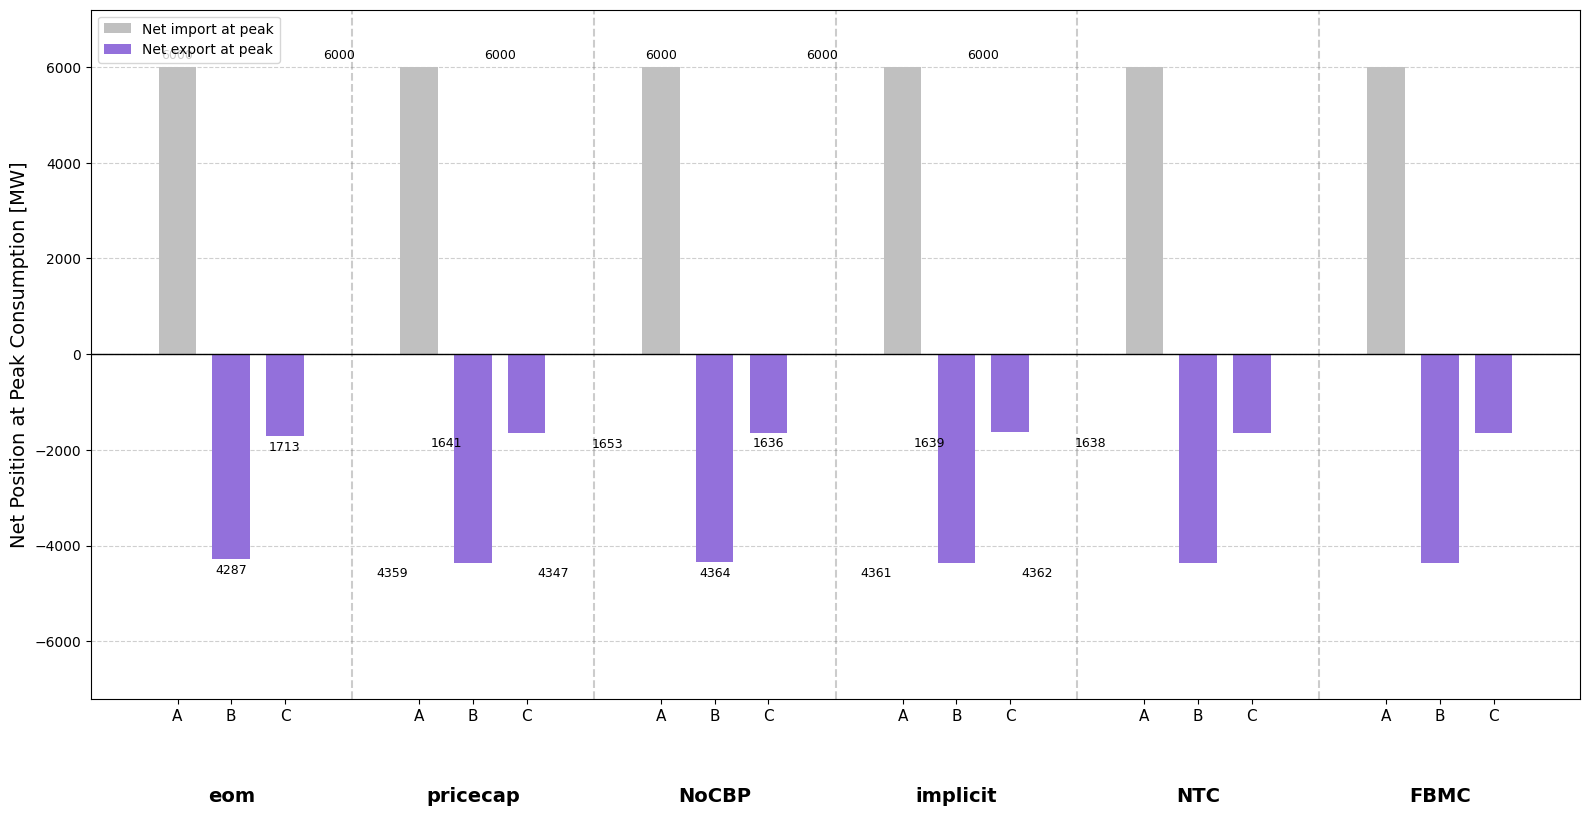


=== Net Imports at Peak Consumption (Planner) ===
   Zone    Design  PeakHour  PeakConsumption  NetImport  NetExport  \
0     A       eom        18         77882.93    6000.00       0.00   
1     B       eom        19         13175.85    1907.47       0.00   
2     C       eom        20         18986.14    3246.90       0.00   
3     A  pricecap        18         67768.74    6000.00       0.00   
4     B  pricecap        19         14519.09    1005.58       0.00   
5     C  pricecap        20         17777.73    1158.74       0.00   
6     A     NoCBP        18         97424.14    6000.00       0.00   
7     B     NoCBP        19         14872.55       0.00     127.45   
8     C     NoCBP        20         19900.77     215.44       0.00   
9     A  implicit        18         97425.44    6000.00       0.00   
10    B  implicit        19         14781.33     413.33       0.00   
11    C  implicit        20         19802.98    3210.13       0.00   
12    A       NTC        18         974

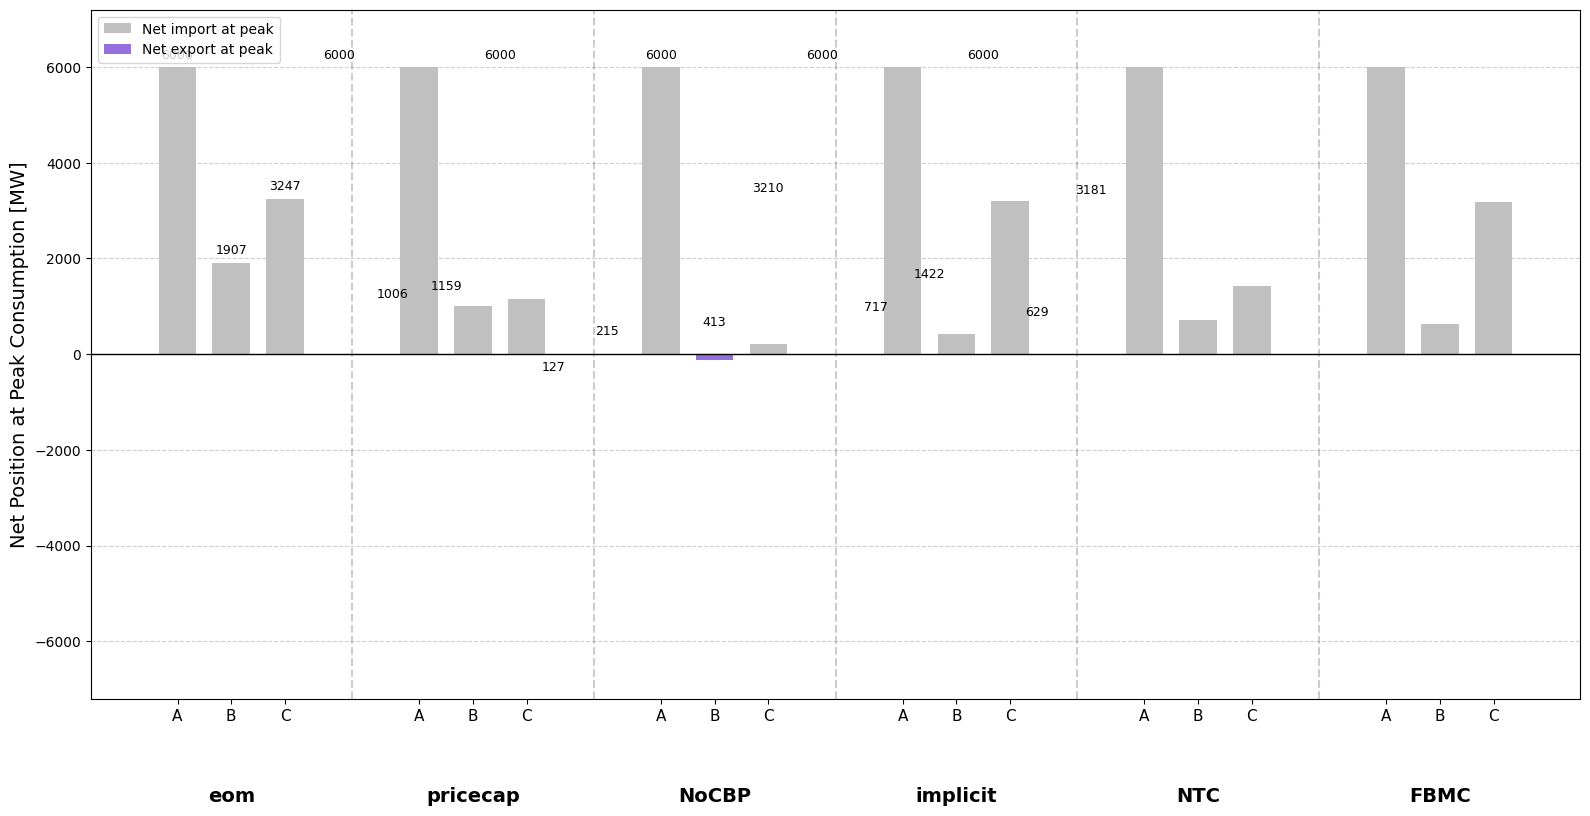

In [60]:
# Compare scarcity imports (at peak consumption) for MCP model
scarcity_imports_mcp = compare_scarcity_imports(analysis_data, source_type="mcp")
print("\n=== Net Imports at Peak Consumption (MCP) ===")
print(scarcity_imports_mcp)
fig, ax = plot_scarcity_imports(scarcity_imports_mcp, source_type="mcp")
plt.show()

# Compare for Planner model
scarcity_imports_planner = compare_scarcity_imports(analysis_data, source_type="planner")
print("\n=== Net Imports at Peak Consumption (Planner) ===")
print(scarcity_imports_planner)
fig, ax = plot_scarcity_imports(scarcity_imports_planner, source_type="planner")
plt.show()

#### Cost analysis

In [35]:
# cost of electricity (€)
# electricity_price*weight(€/MWh) * electricity_demand*weight (MWh)


# cost of unserved energy(€)
# ENS*weight(MWh)
# WTP = 20000 (€/MWh)
# cost of unserved energy = WTP * ENS 



# cost of capacity market (€)
# capacity_market_cost = capacity_price (€/MW) * capacity demand (MW)


# total demand served = (elastic + inelastic demand served).weight (MWh)

# Average prices across zones (€/MWh) =  (cost of electricity (€) + cost of unserved energy(€) + cost of capacity market (€)) / total demand served (MWh)


In [36]:
def extract_cost_data(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, pd.DataFrame]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                result[design][zone] = data[key]
            else:
                print(f"Warning: Missing data for {key}")
    
    return result

In [37]:
# electricity_price_ = extract_cost_data(analysis_data, source_type="mcp")

In [38]:
def compute_cost_metrics(cost_data: Dict[str, Dict[str, pd.DataFrame]], weights: np.ndarray, 
                         wtp: float = 20000) -> pd.DataFrame:

    zones = ["A", "B", "C"]
    design_keys = list(cost_data.keys())
    records = []
    
    for design in design_keys:
        zone_records = []  # Track records for this design
        
        for zone in zones:
            if cost_data[design][zone] is None:
                continue
            
            df = cost_data[design][zone]
            W = weights[:len(df)]  # Get weights for the correct length
            
            # 1. Calculate electricity cost
            elec_price_col = f"EOM_price" if f"EOM_price" in df.columns else "Price"
            elec_demand_col = f"Cons_{zone}" if f"Cons_{zone}" in df.columns else "Demand"

            if elec_price_col in df.columns and elec_demand_col in df.columns:
                # For each timestep: price * demand * weight
                electricity_cost = np.sum(df[elec_price_col] * df[elec_demand_col].abs() * W) # (€/MWh * MWh)
            else:
                print(f"Missing columns for electricity cost calculation in {design} - {zone}")
                electricity_cost = 0
                
            # 2. Calculate unserved energy cost
            ens_col = f"ENS_Cons_{zone}" if f"ENS_Cons_{zone}" in df.columns else "ENS"
            if ens_col in df.columns:
                ens = abs(df[ens_col].values)
                ens_cost = np.sum(ens * W * wtp) # (MWh * €/MWh)
                total_ens = np.sum(ens * W)
            else:
                print(f"Missing ENS column in {design} - {zone}")
                ens_cost = 0
                total_ens = 0
                
            # 3. Calculate capacity market cost
            cap_price_col = f"CM_price" if f"CM_price" in df.columns else "CapacityPrice"
            cap_demand_col = f"CapDemand_Cons_{zone}" if f"CapDemand_Cons_{zone}" in df.columns else "CapacityDemand"
            # cap_offer_col = f"TotalCapOffer" if f"TotalCapOffer" in df.columns else "CapacityOffer"
            
            if cap_price_col in df.columns and cap_demand_col in df.columns:
                cap_price = df[cap_price_col].values[0]
                cap_demand = abs(df[cap_demand_col].values[0])
                capacity_cost = cap_price * cap_demand # (€/MW * MW)
            else:
                capacity_cost = 0
                
            # 4. Calculate total demand served (using electricity demand, not capacity demand)

            total_served = np.sum(abs(df[elec_demand_col].values) * W)
            total_unserved = np.sum(ens * W)
            # total_demand = total_served + total_unserved

            
            # 5. Calculate average price
            total_cost = electricity_cost + ens_cost + capacity_cost
            avg_price = total_cost / total_served if total_served > 0 else 0
            
            record = {
                "Zone": zone,
                "Design": design,
                "ElectricityCost": electricity_cost,
                "ENSCost": ens_cost,
                "CapacityCost": capacity_cost,
                "TotalCost": total_cost,
                "DemandServed": total_served,
                "AveragePrice": avg_price,
                "ENS": total_ens
            }
            
            records.append(record)
            zone_records.append(record)
        
        
        # Calculate system-wide metrics for this design (one per design)
        if zone_records:  # Only if we have zone records for this design
            elec_cost_sum = sum(r["ElectricityCost"] for r in zone_records)
            ens_cost_sum = sum(r["ENSCost"] for r in zone_records)
            cap_cost_sum = sum(r["CapacityCost"] for r in zone_records)
            total_cost_sum = sum(r["TotalCost"] for r in zone_records)
            demand_served_sum = sum(r["DemandServed"] for r in zone_records)
            total_ens = sum(r["ENS"] for r in zone_records)

            # Calculate system-wide average price
            avg_price = total_cost_sum / demand_served_sum if demand_served_sum > 0 else 0
            
            records.append({
                "Zone": "System",
                "Design": design,
                "ElectricityCost": elec_cost_sum,
                "ENSCost": ens_cost_sum,
                "CapacityCost": cap_cost_sum,
                "TotalCost": total_cost_sum,
                "DemandServed": demand_served_sum,
                "AveragePrice": avg_price,
                "ENS": total_ens
            })
    
    return pd.DataFrame(records)

In [39]:
compute_cost_metrics(extract_cost_data(analysis_data, source_type="mcp"), inputs["weights"])

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,2.762465e+10,0.000000e+00,0.000000e+00,2.762465e+10,4.732386e+08,58.373623,0.000000e+00
1,B,eom,3.845242e+09,0.000000e+00,0.000000e+00,3.845242e+09,7.924513e+07,48.523388,0.000000e+00
2,C,eom,5.546076e+09,0.000000e+00,0.000000e+00,5.546076e+09,1.103780e+08,50.246189,0.000000e+00
3,System,eom,3.701597e+10,0.000000e+00,0.000000e+00,3.701597e+10,6.628618e+08,55.842668,0.000000e+00
4,A,pricecap,2.652335e+10,1.831869e+09,0.000000e+00,2.835522e+10,4.731635e+08,59.926895,9.159345e+04
5,B,pricecap,3.886609e+09,5.384209e-06,0.000000e+00,3.886609e+09,7.924479e+07,49.045613,2.692104e-10
6,C,pricecap,5.535071e+09,9.797652e+07,0.000000e+00,5.633047e+09,1.103733e+08,51.036341,4.898826e+03
7,System,pricecap,3.594503e+10,1.929846e+09,0.000000e+00,3.787488e+10,6.627816e+08,57.145339,9.649228e+04
8,A,NoCBP,2.257465e+10,0.000000e+00,4.972251e+09,2.754690e+10,4.732990e+08,58.201904,0.000000e+00
9,B,NoCBP,3.129123e+09,0.000000e+00,1.087885e+09,4.217009e+09,7.925243e+07,53.209835,0.000000e+00


In [40]:
def plot_average_cost_by_zone(cost_metrics: pd.DataFrame):


    fig, ax = plt.subplots(figsize=(16, 8))

    zones = ["A", "B", "C", "System"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors
    base_colors = {
        "A": "#1f77b4",       # Blue
        "B": "#2ca02c",       # Green
        "C": "#9467bd",       # Purple
        "System": "#d62728"   # Red
    }

    # Function to create shades
    def get_shades(hex_color):
        rgb = mcolors.to_rgb(hex_color)
        return {
            "ENERGY": mcolors.to_hex(rgb),                           # original
            "CM": mcolors.to_hex([min(1, c + 0.2) for c in rgb]),    # medium lightness
            "ENS": mcolors.to_hex([min(1, c + 0.4) for c in rgb])   # lightest
        }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = cost_metrics[cost_metrics["Zone"] == zone]
        zone_start_x = current_x
        shades = get_shades(base_colors[zone])

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            energy = row["ElectricityCost"].values[0] / row["DemandServed"].values[0]
            ens = row["ENSCost"].values[0] / row["DemandServed"].values[0]
            cm = row["CapacityCost"].values[0] / row["DemandServed"].values[0]
            total = energy + ens + cm

            # Bars with shade logic
            ax.bar(current_x, energy, width=bar_width, color=shades["ENERGY"])
            ax.bar(current_x, ens, width=bar_width, bottom=energy, color=shades["ENS"])
            ax.bar(current_x, cm, width=bar_width, bottom=energy + ens, color=shades["CM"])

            # Label total on top
            ax.text(current_x, total + 1, f"{total:.2f}", ha="center", va="bottom", fontsize=9)

            # Record positions
            x_positions.append(current_x)
            x_labels.append(design)
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"{zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.2, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Average Cost (€/MWh)', fontsize=13)
    ax.set_ylim(0, max(cost_metrics["AveragePrice"]) * 1.3)
    # ax.set_title("Average Cost to Consumers by Zone and Market Design", fontsize=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Custom legend - fixed colors and better aligned with chart
    sample_shades = get_shades("#777777")  # Neutral color for legend
    
    # Create legend handles and labels separately
    legend_handles = [
        Patch(facecolor=sample_shades["ENERGY"]),
        Patch(facecolor=sample_shades["CM"]),
        Patch(facecolor=sample_shades["ENS"])
    ]
    legend_labels = ['ENERGY', 'CM', 'ENS']
    
    # Add legend with separated handles and labels
    ax.legend(handles=legend_handles, labels=legend_labels, loc='upper left', fontsize=10)

    plt.tight_layout()
    return fig, ax

def analyze_costs(analysis_data, inputs, source_type=""):
    # Extract cost data
    cost_data = extract_cost_data(analysis_data, source_type)
    
    # Compute cost metrics
    cost_metrics = compute_cost_metrics(cost_data, inputs["weights"])
    
    # Create visualizations
    fig, ax = plot_average_cost_by_zone(cost_metrics)
    plt.show()  # Add this to ensure plot is displayed
    return cost_metrics



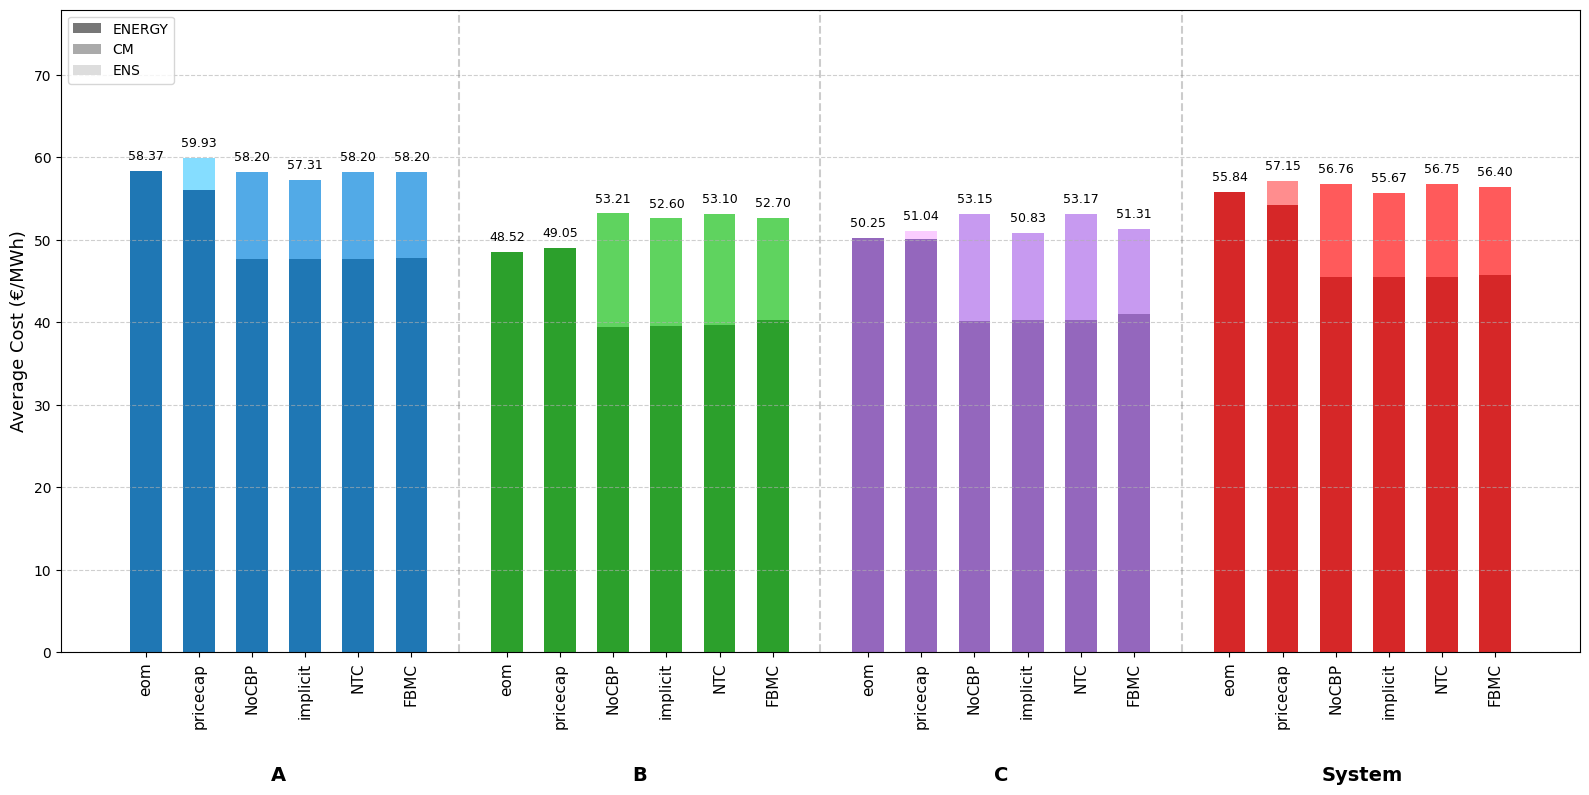

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,2.762465e+10,0.000000e+00,0.000000e+00,2.762465e+10,4.732386e+08,58.373623,0.000000e+00
1,B,eom,3.845242e+09,0.000000e+00,0.000000e+00,3.845242e+09,7.924513e+07,48.523388,0.000000e+00
2,C,eom,5.546076e+09,0.000000e+00,0.000000e+00,5.546076e+09,1.103780e+08,50.246189,0.000000e+00
3,System,eom,3.701597e+10,0.000000e+00,0.000000e+00,3.701597e+10,6.628618e+08,55.842668,0.000000e+00
4,A,pricecap,2.652335e+10,1.831869e+09,0.000000e+00,2.835522e+10,4.731635e+08,59.926895,9.159345e+04
5,B,pricecap,3.886609e+09,5.384209e-06,0.000000e+00,3.886609e+09,7.924479e+07,49.045613,2.692104e-10
6,C,pricecap,5.535071e+09,9.797652e+07,0.000000e+00,5.633047e+09,1.103733e+08,51.036341,4.898826e+03
7,System,pricecap,3.594503e+10,1.929846e+09,0.000000e+00,3.787488e+10,6.627816e+08,57.145339,9.649228e+04
8,A,NoCBP,2.257465e+10,0.000000e+00,4.972251e+09,2.754690e+10,4.732990e+08,58.201904,0.000000e+00
9,B,NoCBP,3.129123e+09,0.000000e+00,1.087885e+09,4.217009e+09,7.925243e+07,53.209835,0.000000e+00


In [41]:
analyze_costs(analysis_data, inputs, source_type="mcp")

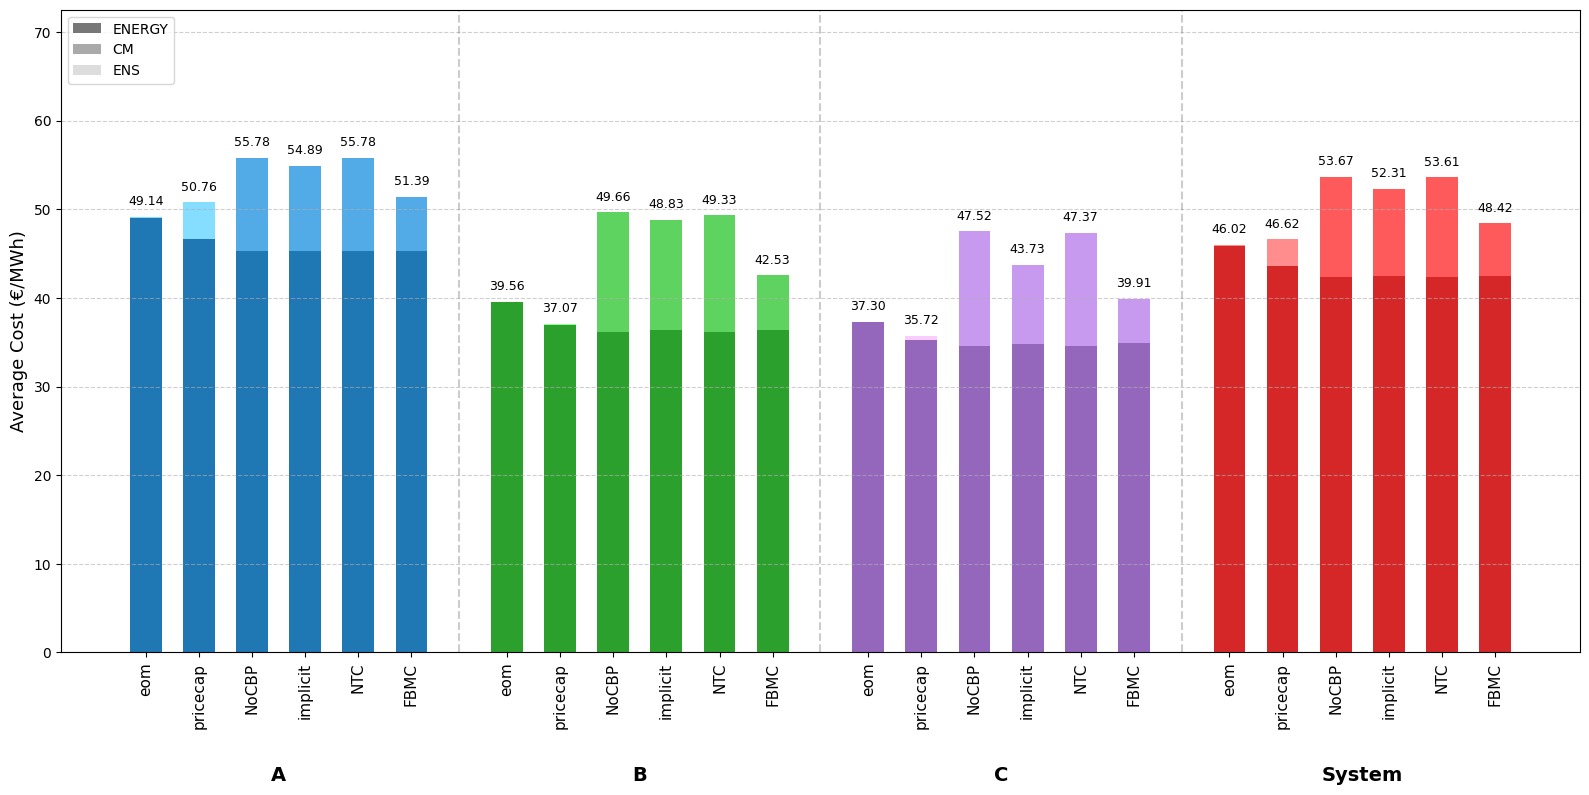

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,2.316910e+10,8.468400e+07,0.000000e+00,2.325378e+10,4.732475e+08,49.136625,4234.20
1,B,eom,3.135174e+09,0.000000e+00,0.000000e+00,3.135174e+09,7.924704e+07,39.562034,0.00
2,C,eom,4.116925e+09,0.000000e+00,0.000000e+00,4.116925e+09,1.103839e+08,37.296436,0.00
3,System,eom,3.042120e+10,8.468400e+07,0.000000e+00,3.050588e+10,6.628784e+08,46.020331,4234.20
4,A,pricecap,2.205843e+10,1.960940e+09,0.000000e+00,2.401937e+10,4.731689e+08,50.762774,98047.00
5,B,pricecap,2.925295e+09,1.212920e+07,0.000000e+00,2.937425e+09,7.924719e+07,37.066610,606.46
6,C,pricecap,3.886298e+09,5.689120e+07,0.000000e+00,3.943189e+09,1.103812e+08,35.723378,2844.56
7,System,pricecap,2.887002e+10,2.029960e+09,0.000000e+00,3.089998e+10,6.627973e+08,46.620559,101498.02
8,A,NoCBP,2.143018e+10,0.000000e+00,4.972250e+09,2.640243e+10,4.733104e+08,55.782481,0.00
9,B,NoCBP,2.864217e+09,0.000000e+00,1.071441e+09,3.935658e+09,7.925508e+07,49.658114,0.00


In [42]:
analyze_costs(analysis_data, inputs, source_type="planner")

In [43]:
def compare_mcp_planner_costs(analysis_data, inputs):
    """
    Create a component bar chart comparing MCP and planner cost results
    using consistent styling with other visualizations
    """
    # Get cost metrics for both sources
    mcp_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "mcp"), inputs["weights"])
    planner_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "planner"), inputs["weights"])
    
    # Filter to just get system-wide metrics
    mcp_system = mcp_metrics[mcp_metrics["Zone"] == "System"].copy()
    planner_system = planner_metrics[planner_metrics["Zone"] == "System"].copy()
    
    # Prepare data for plotting
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Set up parameters for plotting
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    bar_width = 0.35
    x = np.arange(len(design_order))
    
    # Use same color scheme as plot_average_cost_by_zone
    mcp_base = "#9467bd"     # Purple (MCP color)
    planner_base = "#C0C0C0"  # Gray (Planner color)


    # Function to create shades (exactly as in plot_average_cost_by_zone)
    def get_shades(hex_color):
        rgb = mcolors.to_rgb(hex_color)
        return {
            "ENERGY": mcolors.to_hex(rgb),                           # original
            "CM": mcolors.to_hex([min(1, c + 0.1) for c in rgb]),   # medium lightness
            "ENS": mcolors.to_hex([min(1, c + 0.2) for c in rgb])    # lightest
        }
    
    # Get color shades for both sources
    mcp_colors = get_shades(mcp_base)
    planner_colors = get_shades(planner_base)
    
    # Track positions for bar labels
    mcp_heights = {}
    planner_heights = {}
    
    # Plot MCP costs
    for i, design in enumerate(design_order):
        mcp_row = mcp_system[mcp_system["Design"] == design]
        if not mcp_row.empty:
            # Calculate components per MWh
            energy = mcp_row["ElectricityCost"].values[0] / mcp_row["DemandServed"].values[0]
            ens = mcp_row["ENSCost"].values[0] / mcp_row["DemandServed"].values[0]
            cm = mcp_row["CapacityCost"].values[0] / mcp_row["DemandServed"].values[0]
            
            # Plot stacked bars with consistent naming (ENERGY instead of Energy)
            ax.bar(x[i] - bar_width/2, energy, width=bar_width, color=mcp_colors["ENERGY"], 
                   label="MCP ENERGY" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, ens, width=bar_width, bottom=energy, color=mcp_colors["ENS"], 
                   label="MCP ENS" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, cm, width=bar_width, bottom=energy+ens, color=mcp_colors["CM"], 
                   label="MCP CM" if i == 0 else "")
            
            # Store total height for labeling
            mcp_heights[design] = energy + ens + cm
    
    # Plot Planner costs
    for i, design in enumerate(design_order):
        planner_row = planner_system[planner_system["Design"] == design]
        if not planner_row.empty:
            # Calculate components per MWh
            energy = planner_row["ElectricityCost"].values[0] / planner_row["DemandServed"].values[0]
            ens = planner_row["ENSCost"].values[0] / planner_row["DemandServed"].values[0]
            cm = planner_row["CapacityCost"].values[0] / planner_row["DemandServed"].values[0]
            
            # Plot stacked bars with consistent naming
            ax.bar(x[i] + bar_width/2, energy, width=bar_width, color=planner_colors["ENERGY"], 
                   label="Planner ENERGY" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, ens, width=bar_width, bottom=energy, color=planner_colors["ENS"], 
                   label="Planner ENS" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, cm, width=bar_width, bottom=energy+ens, color=planner_colors["CM"], 
                   label="Planner CM" if i == 0 else "")
            
            # Store total height for labeling
            planner_heights[design] = energy + ens + cm
    
    # Calculate max height for proper y-axis scaling
    max_height = max(max(mcp_heights.values()) if mcp_heights else 0,
                     max(planner_heights.values()) if planner_heights else 0)
    
    ax.set_ylim(0, max_height * 1.10)  # Add 10% padding at the top
    
    # Add labels and values on top of bars
    for i, design in enumerate(design_order):
        if design in mcp_heights:
            ax.text(x[i] - bar_width/2, mcp_heights[design] + max_height * 0.02, 
                    f"{mcp_heights[design]:.2f}", 
                    ha='center', va='bottom', fontsize=9)
        if design in planner_heights:
            ax.text(x[i] + bar_width/2, planner_heights[design] + max_height * 0.02, 
                    f"{planner_heights[design]:.2f}", 
                    ha='center', va='bottom', fontsize=9)
    
    # Customize plot
    ax.set_ylabel('Average Cost (€/MWh)', fontsize=13)
    # ax.set_title('Comparison of Average System Costs: MCP vs Planner', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(design_order)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    
    # Create custom legend with patches using same style as plot_average_cost_by_zone
    legend_elements = [
        Patch(facecolor=mcp_colors["ENERGY"], label='MCP ENERGY'),
        Patch(facecolor=mcp_colors["CM"], label='MCP CM'),
        Patch(facecolor=mcp_colors["ENS"], label='MCP ENS'),
        Patch(facecolor=planner_colors["ENERGY"], label='Planner ENERGY'),
        Patch(facecolor=planner_colors["CM"], label='Planner CM'),
        Patch(facecolor=planner_colors["ENS"], label='Planner ENS'),

    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
    
    plt.tight_layout()
    return fig, ax

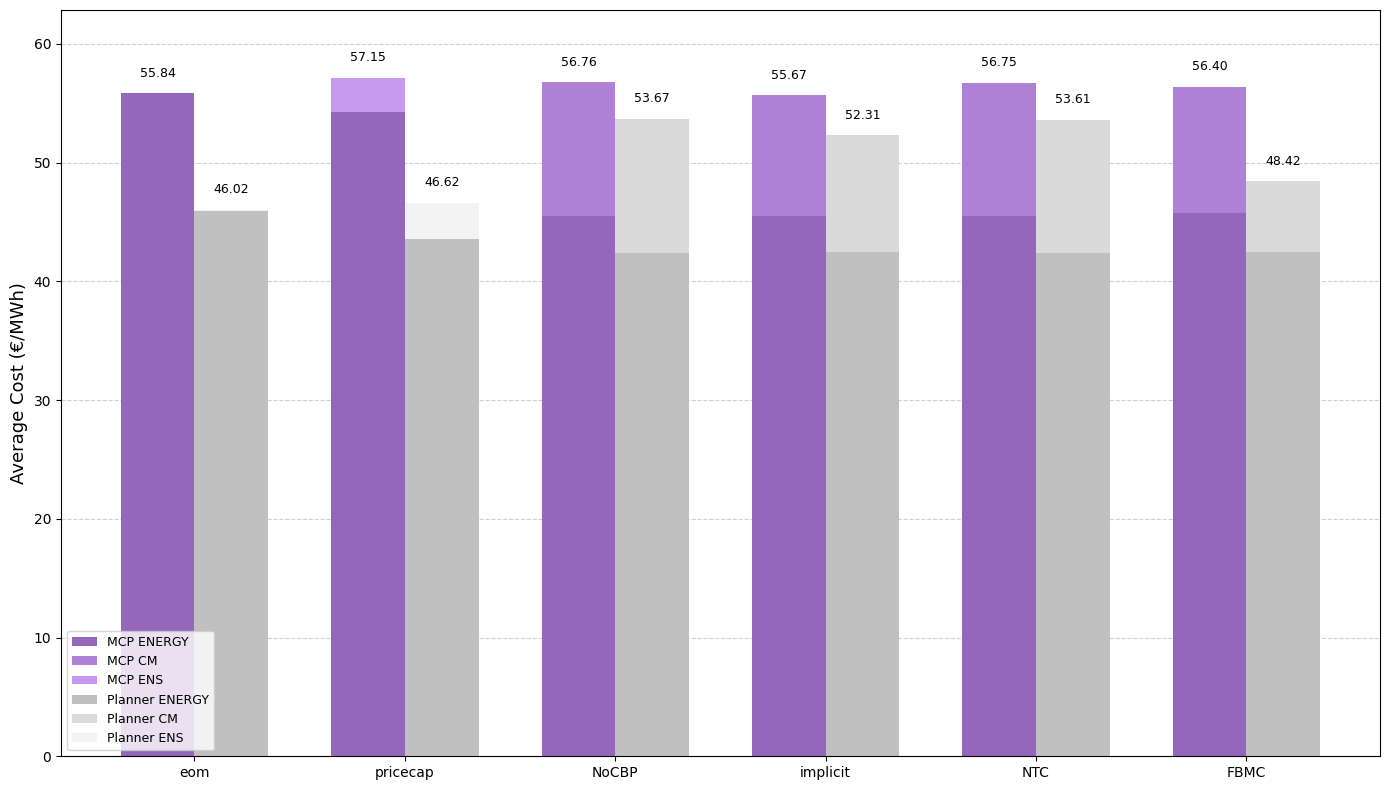

In [44]:
# function call
fig, ax = compare_mcp_planner_costs(analysis_data, inputs)

In [45]:
# Capacity trade

# FB - MCP / Planner
# Zone A – import 1225 / 1000
# Zone B – import 4775 / 5000
# Zone C – export 6000 / 6000

# NTC - MCP / Planner
# Zone A – import 4058 / 1302
# Zone B – import 680 / 3435.8
# Zone C – export 4738 / 4738



In [46]:
# plot scarcity price 
# look for max price in EOM_price column for each zone and design
# plot bar chart with scarcity prices for each zone and design


In [47]:
def extract_scarcity_prices(data: Dict[str, pd.DataFrame], source_type: str = "mcp") -> pd.DataFrame:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found in analysis data")
                continue
            
            df = data[key]
            
            # Find maximum EOM price (scarcity price)
            if "EOM_price" in df.columns:
                max_price = df["EOM_price"].max()
                records.append({
                    "Zone": zone,
                    "Design": design,
                    "ScarcityPrice": max_price
                })
            else:
                print(f"Warning: EOM_price column not found in {key}")
    
    return pd.DataFrame(records)

def plot_scarcity_price_by_zone(scarcity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot scarcity prices by zone and market design with consistent styling
    similar to plot_average_cost_by_zone
    """
    fig, ax = plt.subplots(figsize=(16, 8))

    zones = ["A", "B", "C"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors (matching plot_average_cost_by_zone)
    base_colors = {
        "A": "#1f77b4",       # Blue
        "B": "#2ca02c",       # Green
        "C": "#9467bd",       # Purple
    }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = scarcity_df[scarcity_df["Zone"] == zone]
        zone_start_x = current_x
        color = base_colors[zone]

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            scarcity_price = row["ScarcityPrice"].values[0]

            # Plot bar
            ax.bar(current_x, scarcity_price, width=bar_width, color=color)

            # Label value on top
            ax.text(current_x, scarcity_price + scarcity_df["ScarcityPrice"].max() * 0.02, 
                   f"{scarcity_price:.0f}", ha="center", va="bottom", fontsize=0)

            # Record positions
            x_positions.append(current_x)
            x_labels.append(design)
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"Zone {zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=13, rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.2, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Scarcity Price (€/MWh)', fontsize=13)
    ax.set_ylim(0, scarcity_df["ScarcityPrice"].max() * 1.2)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Create legend with zone colors
    legend_elements = [
        Patch(facecolor=base_colors["A"], label='Zone A'),
        Patch(facecolor=base_colors["B"], label='Zone B'),
        Patch(facecolor=base_colors["C"], label='Zone C')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    plt.tight_layout()
    return fig, ax

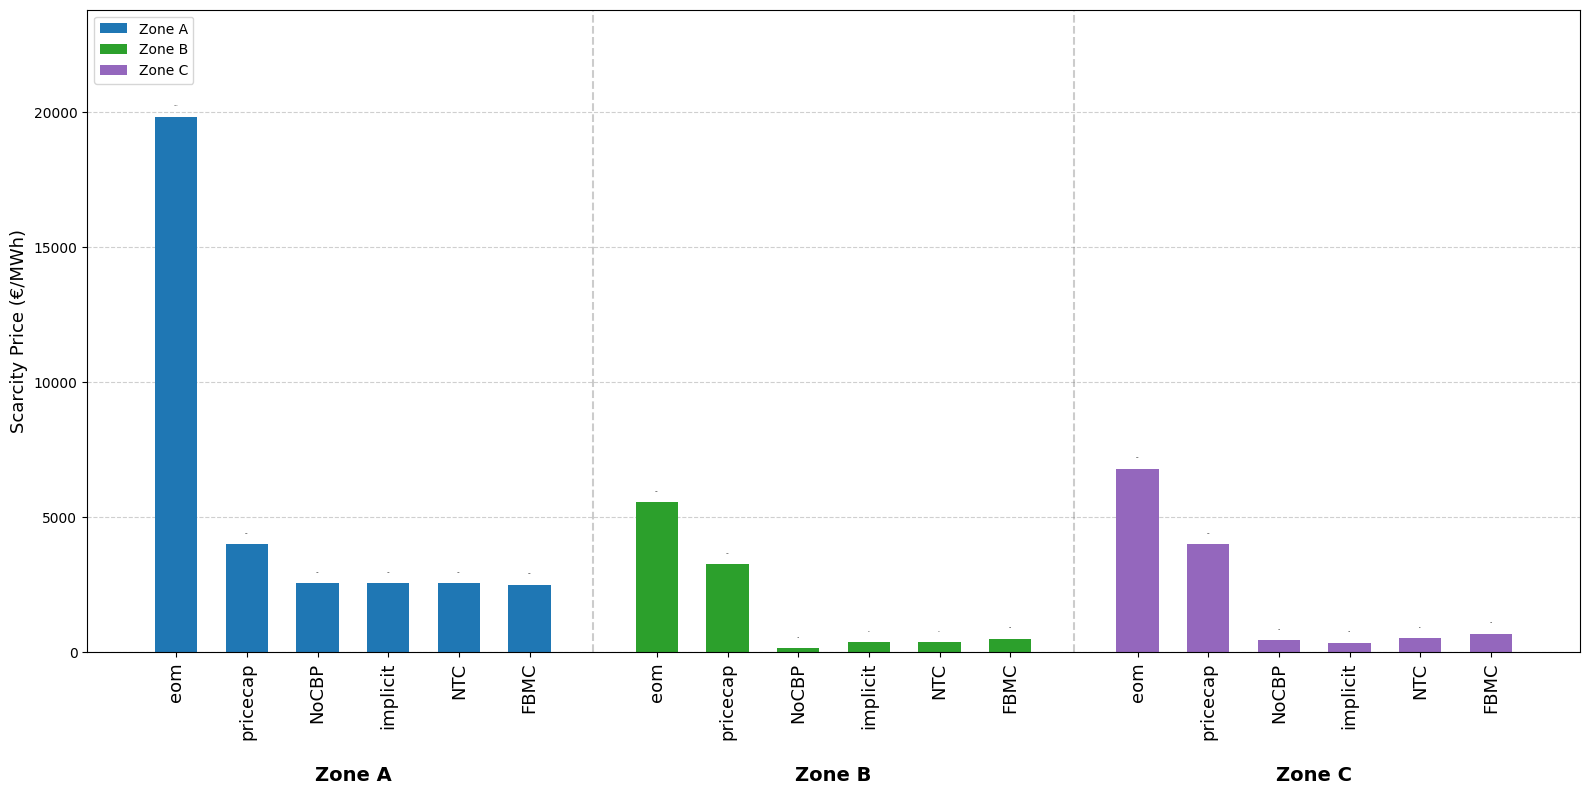

In [48]:
# Extract and plot scarcity prices for MCP model
scarcity_prices_mcp = extract_scarcity_prices(analysis_data, source_type="mcp")
fig, ax = plot_scarcity_price_by_zone(scarcity_prices_mcp, source_type="mcp")
plt.show()

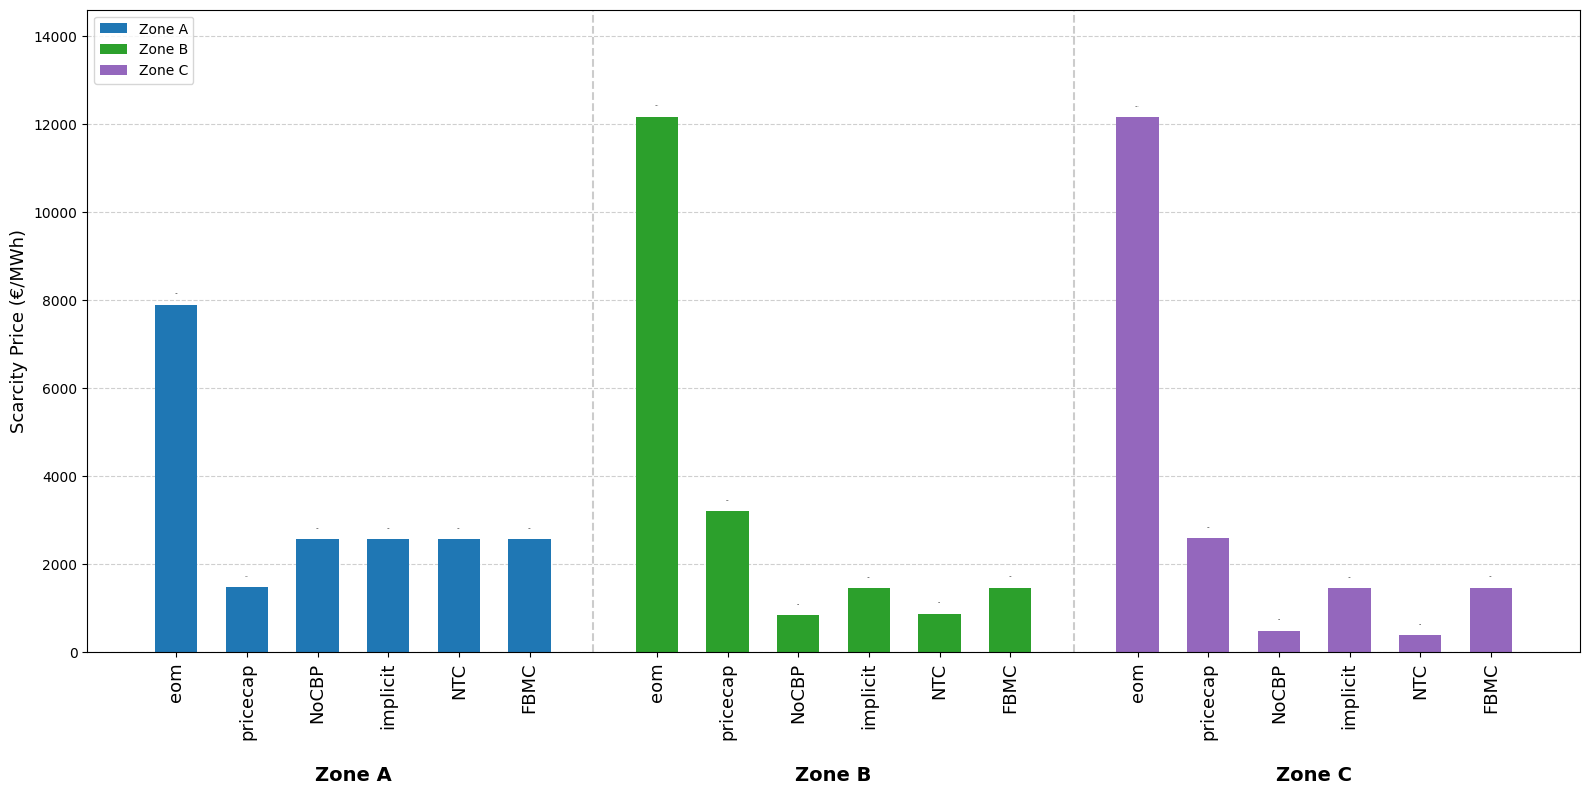

In [49]:
# For Planner model
scarcity_prices_planner = extract_scarcity_prices(analysis_data, source_type="planner")
fig, ax = plot_scarcity_price_by_zone(scarcity_prices_planner, source_type="planner")
plt.show()

In [50]:
def extract_capacity_prices(data: Dict[str, pd.DataFrame], source_type: str = "mcp") -> pd.DataFrame:
    """
    Extract capacity market prices (CM_price) for each zone and market design
    """
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found in analysis data")
                continue
            
            df = data[key]
            
            # Get capacity market price (typically constant across timesteps)
            if "CM_price" in df.columns:
                cm_price = df["CM_price"].iloc[0]  # Usually constant

                
                records.append({
                    "Zone": zone,
                    "Design": design,
                    "CapacityPrice": cm_price
                })
            else:
                continue
                print(f"Warning: CM_price column not found in {key}")
    
    return pd.DataFrame(records)


def plot_capacity_price_by_zone(capacity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot capacity market prices by zone and market design with consistent styling
    similar to plot_scarcity_price_by_zone
    """
    fig, ax = plt.subplots(figsize=(16, 8))

    zones = ["A", "B", "C"]
    design_order = ["NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors (matching other plots)
    base_colors = {
        "A": "#1f77b4",       # Blue
        "B": "#2ca02c",       # Green
        "C": "#9467bd",       # Purple
    }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = capacity_df[capacity_df["Zone"] == zone]
        zone_start_x = current_x
        color = base_colors[zone]

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            capacity_price = row["CapacityPrice"].values[0]

            # Plot bar
            ax.bar(current_x, capacity_price, width=bar_width, color=color)

            # Label value on top (only if non-zero)
            if capacity_price > 0:
                max_price = capacity_df["CapacityPrice"].max()
                ax.text(current_x, capacity_price + max_price * 0.02, 
                       f"{capacity_price:.0f}", ha="center", va="bottom", fontsize=9)

            # Record positions
            x_positions.append(current_x)
            x_labels.append(design)
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"Zone {zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.2, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Capacity Price (€/MW)', fontsize=13)
    
    # Set y-axis limit (handle case where all prices are zero)
    max_price = capacity_df["CapacityPrice"].max()
    if max_price > 0:
        ax.set_ylim(0, max_price * 1.2)
    else:
        ax.set_ylim(0, 100)  # Default range if all prices are zero
    
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Create legend with zone colors
    legend_elements = [
        Patch(facecolor=base_colors["A"], label='Zone A'),
        Patch(facecolor=base_colors["B"], label='Zone B'),
        Patch(facecolor=base_colors["C"], label='Zone C')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    plt.tight_layout()
    return fig, ax


Capacity Prices (MCP):
   Zone    Design  CapacityPrice
0     A       eom       0.000000
1     B       eom       0.000000
2     C       eom       0.000000
3     A  pricecap       0.000000
4     B  pricecap       0.000000
5     C  pricecap       0.000000
6     A     NoCBP   70000.000000
7     B     NoCBP   74999.999998
8     C     NoCBP   79943.615014
9     A  implicit   70000.000000
10    B  implicit   74256.425258
11    C  implicit   79603.034938
12    A       NTC   70000.000000
13    B       NTC   73505.866877
14    C       NTC   79556.058655
15    A      FBMC   70000.000000
16    B      FBMC   70740.680773
17    C      FBMC   71132.838165


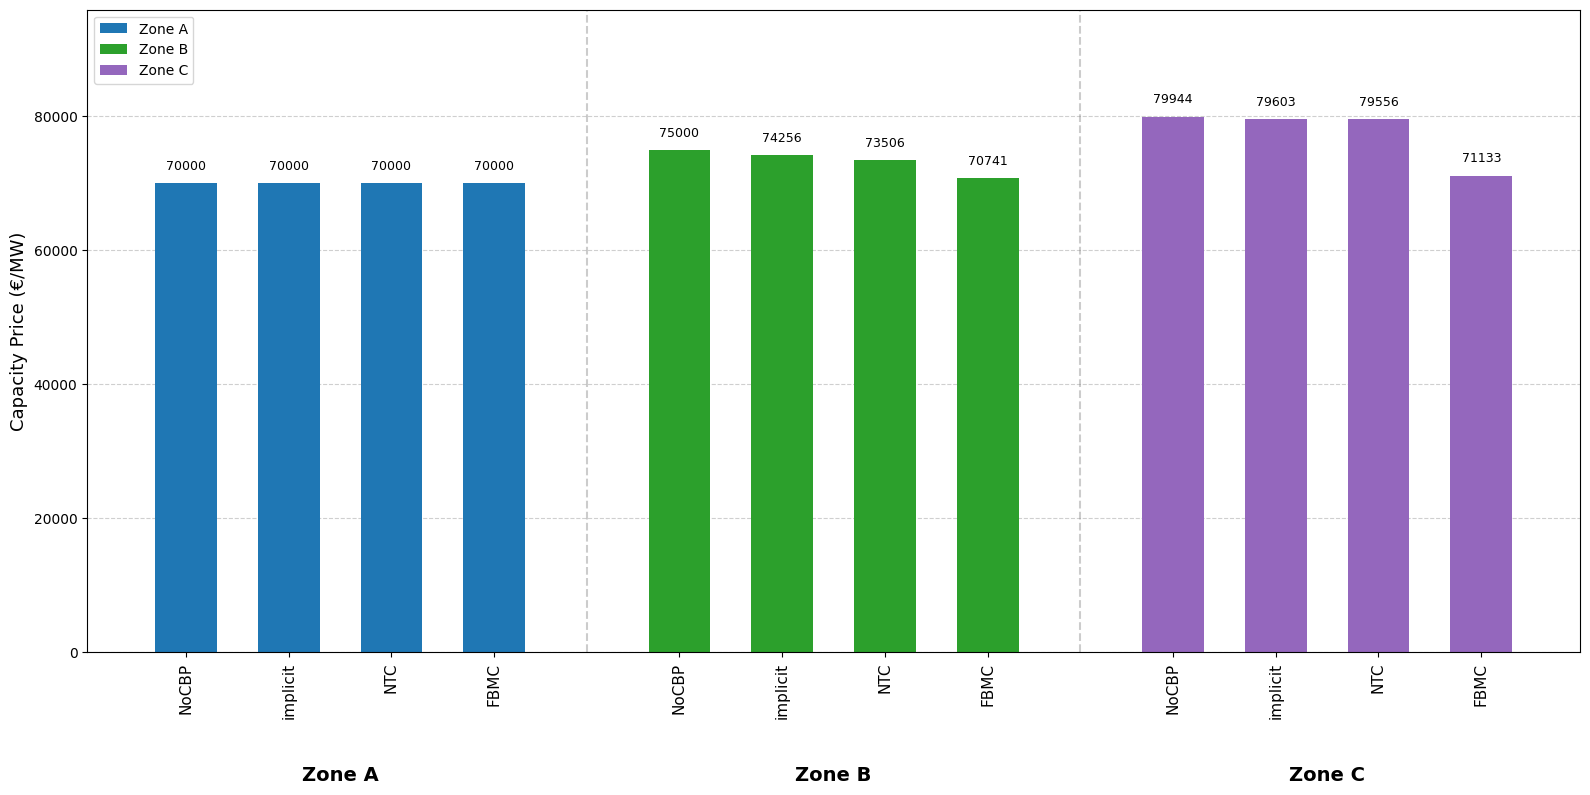


Capacity Prices (Planner):
   Zone    Design  CapacityPrice
0     A     NoCBP       70000.00
1     B     NoCBP       73866.30
2     C     NoCBP       80000.00
3     A  implicit       70000.00
4     B  implicit       71016.10
5     C  implicit       66931.06
6     A       NTC       70000.00
7     B       NTC       72055.49
8     C       NTC       79038.07
9     A      FBMC       41119.64
10    B      FBMC       34992.23
11    C      FBMC       35014.84


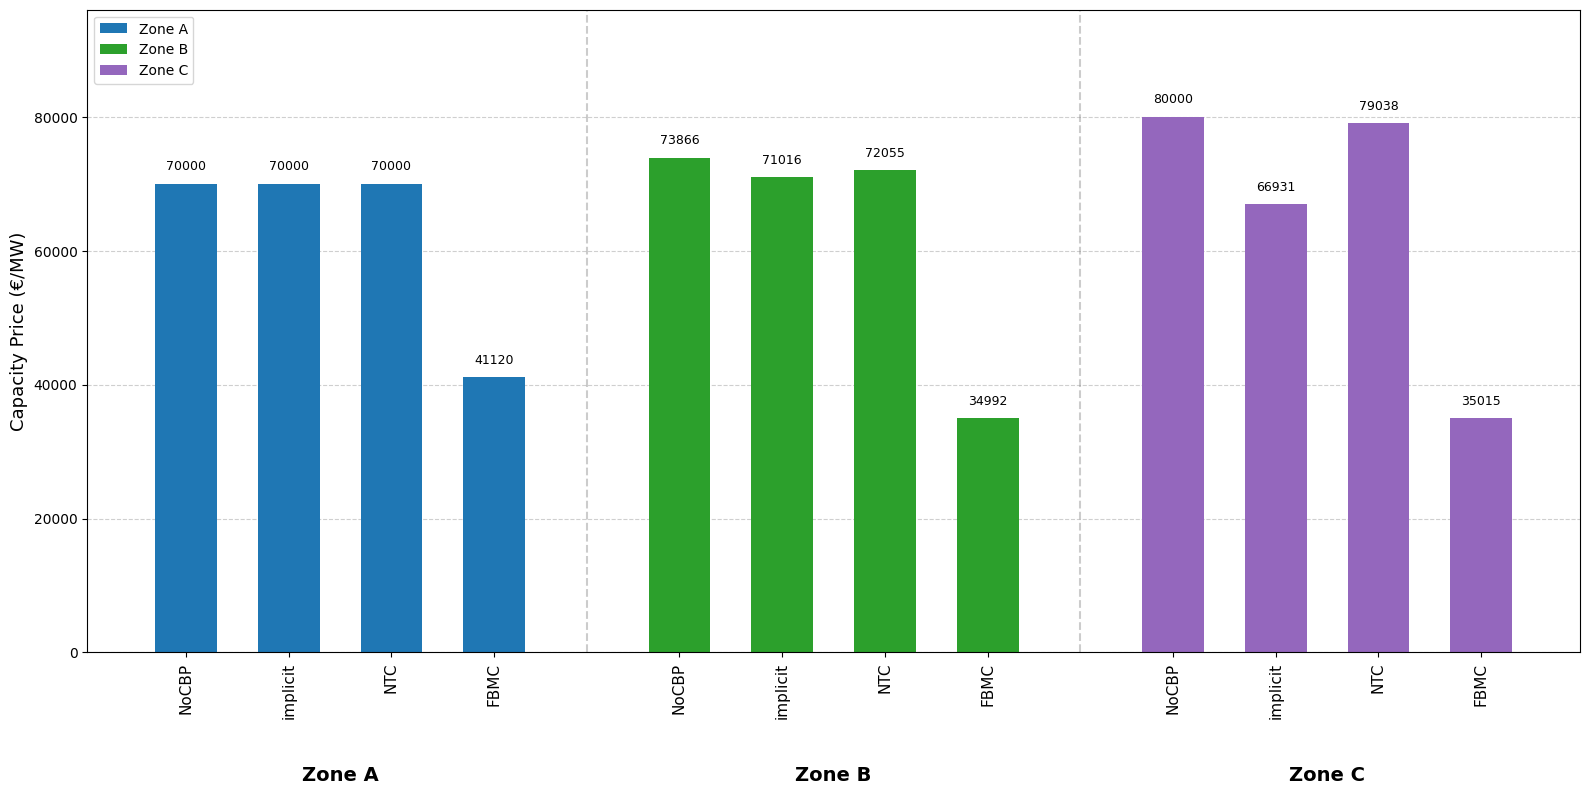

In [51]:
# capacity price in each zone
# Extract and plot capacity prices for MCP model
capacity_prices_mcp = extract_capacity_prices(analysis_data, source_type="mcp")
print("\nCapacity Prices (MCP):")
print(capacity_prices_mcp)
fig, ax = plot_capacity_price_by_zone(capacity_prices_mcp, source_type="mcp")
plt.show()

# For Planner model
capacity_prices_planner = extract_capacity_prices(analysis_data, source_type="planner")
print("\nCapacity Prices (Planner):")
print(capacity_prices_planner)
fig, ax = plot_capacity_price_by_zone(capacity_prices_planner, source_type="planner")
plt.show()


In [52]:
def compare_mcp_planner_capacity_prices(analysis_data):

    # Get capacity price data for both sources
    mcp_capacity = extract_capacity_prices(analysis_data, "mcp")
    planner_capacity = extract_capacity_prices(analysis_data, "planner")
    
    # Filter to only include designs with capacity markets
    design_order = ["NoCBP", "implicit", "NTC", "FBMC"]
    mcp_capacity = mcp_capacity[mcp_capacity["Design"].isin(design_order)]
    planner_capacity = planner_capacity[planner_capacity["Design"].isin(design_order)]
    
    # Calculate system-wide averages for each design
    for design in design_order:
        # MCP system average
        mcp_design_data = mcp_capacity[mcp_capacity["Design"] == design]
        if not mcp_design_data.empty:
            avg_price = mcp_design_data["CapacityPrice"].mean()
            mcp_capacity = pd.concat([mcp_capacity, pd.DataFrame({
                "Zone": ["System"],
                "Design": [design],
                "CapacityPrice": [avg_price]
            })], ignore_index=True)
        
        # Planner system average
        planner_design_data = planner_capacity[planner_capacity["Design"] == design]
        if not planner_design_data.empty:
            avg_price = planner_design_data["CapacityPrice"].mean()
            planner_capacity = pd.concat([planner_capacity, pd.DataFrame({
                "Zone": ["System"],
                "Design": [design],
                "CapacityPrice": [avg_price]
            })], ignore_index=True)
    
    # Prepare data for plotting
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Set up parameters for plotting - now including System
    zones = ["A", "B", "C", "System"]
    bar_width = 0.35
    
    # Use same color scheme as compare_mcp_planner_costs
    mcp_base = "#9467bd"     # Purple (MCP color)
    planner_base = "#C0C0C0"  # Gray (Planner color)
    
    # Bar settings
    spacing_between_designs = 1.5
    current_x = 0
    x_positions_mcp = []
    x_positions_planner = []
    x_labels = []
    design_label_positions = []
    design_boundaries = []
    
    for design in design_order:
        design_start_x = current_x
        
        for zone in zones:
            # Get MCP capacity price
            mcp_row = mcp_capacity[(mcp_capacity["Design"] == design) & 
                                    (mcp_capacity["Zone"] == zone)]
            mcp_price = mcp_row["CapacityPrice"].values[0] if not mcp_row.empty else 0
            
            # Get Planner capacity price
            planner_row = planner_capacity[(planner_capacity["Design"] == design) & 
                                            (planner_capacity["Zone"] == zone)]
            planner_price = planner_row["CapacityPrice"].values[0] if not planner_row.empty else 0
            
            # Plot MCP bar (left) - using purple color
            ax.bar(current_x - bar_width/2, mcp_price, width=bar_width, 
                   color=mcp_base, alpha=0.8, 
                   label=f"MCP" if design == design_order[0] and zone == zones[0] else "")
            
            # Plot Planner bar (right) - using gray color
            ax.bar(current_x + bar_width/2, planner_price, width=bar_width, 
                   color=planner_base, alpha=0.8, 
                   label=f"Planner" if design == design_order[0] and zone == zones[0] else "")
            
            # # Add value labels on top (only if non-zero)
            # max_price = max(
            #     mcp_capacity["CapacityPrice"].max() if len(mcp_capacity) > 0 else 0,
            #     planner_capacity["CapacityPrice"].max() if len(planner_capacity) > 0 else 0
            # )
            # if mcp_price > 0:
            #     ax.text(current_x - bar_width/2, mcp_price + max_price * 0.02, 
            #            f"{mcp_price:.0f}", ha='center', va='bottom', fontsize=0)
            # if planner_price > 0:
            #     ax.text(current_x + bar_width/2, planner_price + max_price * 0.02, 
            #            f"{planner_price:.0f}", ha='center', va='bottom', fontsize=0)
            
            # Record positions
            x_positions_mcp.append(current_x - bar_width/2)
            x_positions_planner.append(current_x + bar_width/2)
            x_labels.append(zone)
            current_x += 1
        
        # Design mid label
        if current_x > design_start_x:
            mid = (design_start_x + current_x - 1) / 2
            design_label_positions.append((mid, design))
            design_boundaries.append(current_x - 0.5)
            current_x += spacing_between_designs
    
    # X-axis labels for zones
    all_x_positions = []
    for i in range(len(x_positions_mcp)):
        all_x_positions.append((x_positions_mcp[i] + x_positions_planner[i]) / 2)
    
    ax.set_xticks(all_x_positions)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=0)
    
    # Design labels under x-axis
    for xpos, label in design_label_positions:
        ax.text(xpos, -0.15, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=14, fontweight='bold')
    
    # Vertical lines between designs
    for boundary in design_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_designs / 2, color='gray', 
                   linestyle='--', alpha=0.4)
    
    # Styling
    ax.set_ylabel('Capacity Price (€/MW)', fontsize=13)
    
    # Set y-axis limit
    max_price = max(
        mcp_capacity["CapacityPrice"].max() if len(mcp_capacity) > 0 else 0,
        planner_capacity["CapacityPrice"].max() if len(planner_capacity) > 0 else 0
    )
    if max_price > 0:
        ax.set_ylim(0, max_price * 1.2)
    else:
        ax.set_ylim(0, 100)
    
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    
    # Simple legend matching compare_mcp_planner_costs style
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=mcp_base, alpha=0.8, label='MCP'),
        Patch(facecolor=planner_base, alpha=0.8, label='Planner'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)  # Make room for design labels
    return fig, ax

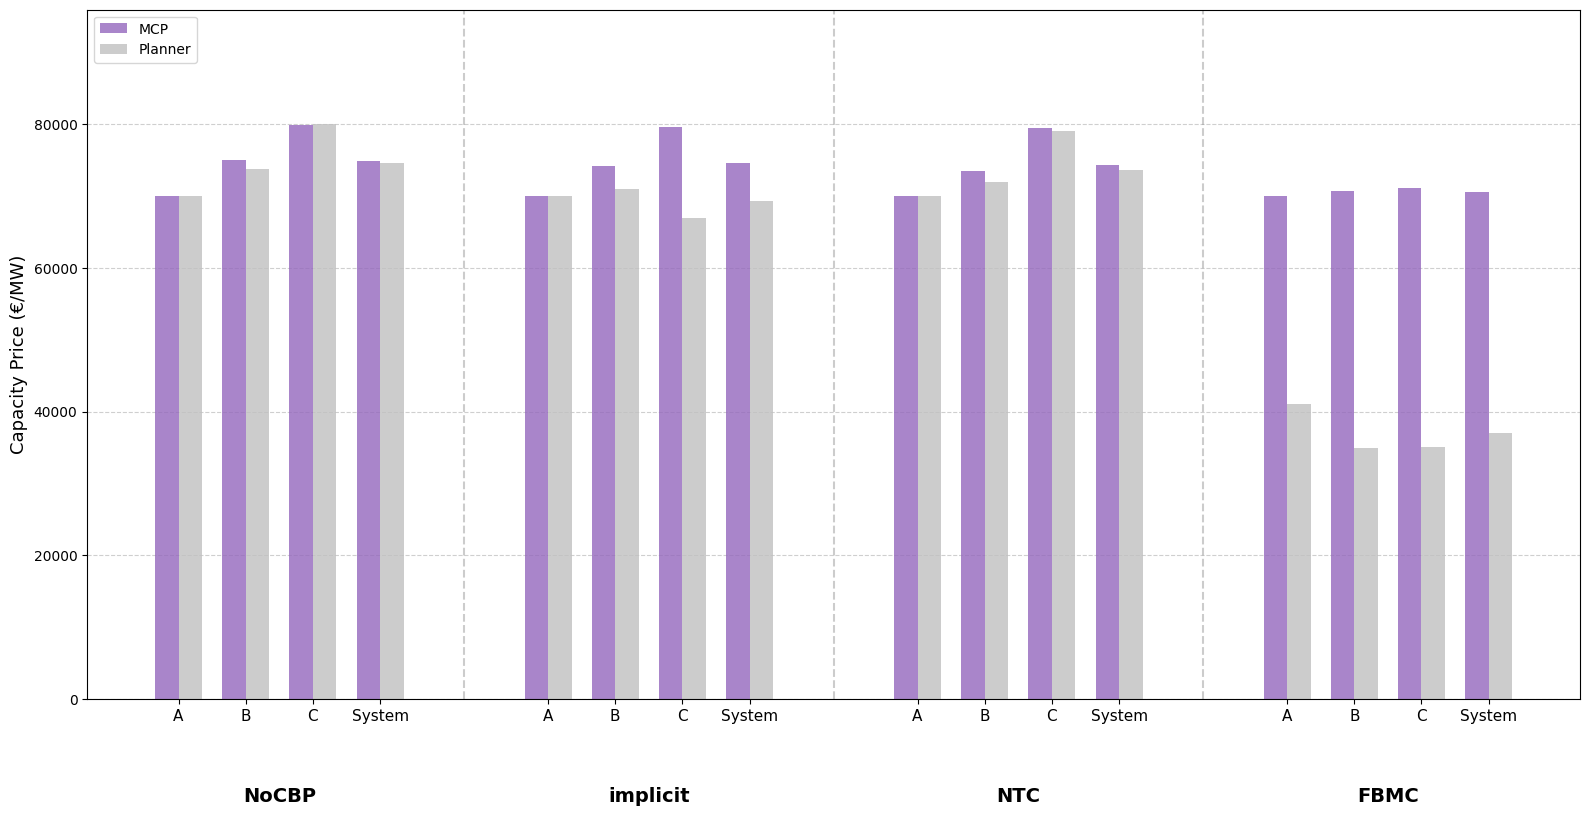

In [53]:
# Compare MCP and Planner capacity prices
fig, ax = compare_mcp_planner_capacity_prices(analysis_data)
plt.show()

### Sensitivity

In [54]:
# sensitivity of average cost to interconnector capacity

In [55]:
# Demand curve

Calibration parameter e: 0.2000
Elasticity at price cap (when Q=D_z): 0.0400 (target: 0.04)

Inelastic demand d_inel: 0.8000 (80.00% of D_z)
Elastic demand at price cap: 0.1600 (16.00% of D_z)

Slope dp/dQ: -100000.00 €/MWh per MW

Verification:
Total demand at price cap: 0.9599 D_z (target: 0.96 D_z)
Elasticity at price cap: 0.0417 (target: 0.04)
Elasticity at w_max: 0.2500 (target: 0.20)
Total demand at p=0: 1.0000 D_z (100.00% of D_z)


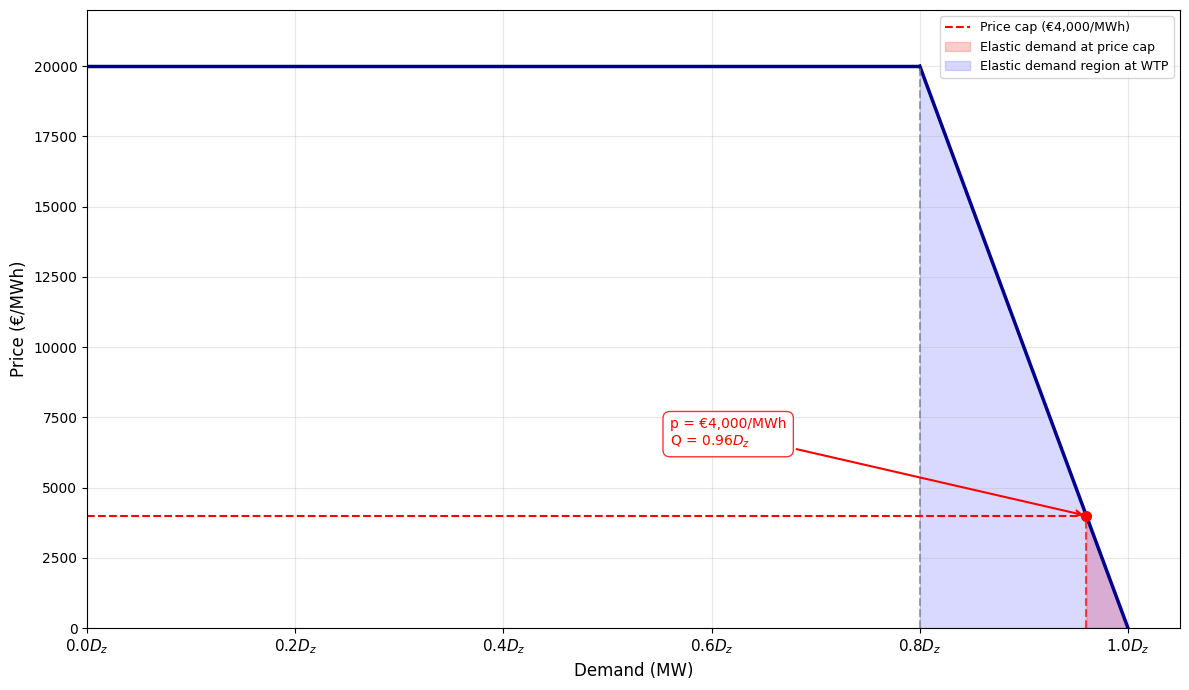


=== Summary ===
Parameter                           Value                Formula
--------------------------------------------------------------------------------
Calibration e                       0.2000                 ε₀(w/p₀)
Inelastic demand (d_inel)           0.8000 D_z (80.0%)  Q_cap - elastic_cap
Demand at price cap                 0.9599 D_z (96.0%)  d_inel + (eD_z/w)(w-p)
Elastic at price cap                0.1600 D_z (16.0%)
Demand at p=0                       1.0000 D_z (100.0%)
Elasticity at w_max                 0.2500                 -e(w/Q)
Elasticity at price cap             0.0417                 -(eD_z/w)(p/Q)
Slope (dp/dQ)                       -100000.00 €/MWh/MW    -w/(eD_z)


In [56]:

# Parameters
w_max = 20000      # Max willingness to pay (€/MWh)
price_cap = 4000   # Price cap (€/MWh)
D_z = 1.0          # Normalized total reference demand

# Target elasticities (absolute values)
epsilon_at_wmax = 0.20    # 20% elasticity at w_max
epsilon_at_cap = 0.04     # 4% elasticity at price_cap

# Step 1: Calibrate e using equation (8): e = -ε(p) * (w/p)
# At p = w_max, we want |ε| = 0.20
# Since we're at the top of the demand curve, let's use this point
e = epsilon_at_wmax * (w_max / w_max)  # This gives e = 0.20
print(f"Calibration parameter e: {e:.4f}")

# Verify: At price_cap, with e = 0.20, what's the elasticity?
# From equation (7): ε(p) = -e * (p/w) when Q = D_z
# At p = 4000: ε = -0.20 * (4000/20000) = -0.04 ✓
epsilon_check_cap = e * (price_cap / w_max)
print(f"Elasticity at price cap (when Q=D_z): {epsilon_check_cap:.4f} (target: 0.04)")

# Step 2: Determine d_inel from the constraint that at price_cap, Q_tot = 0.96*D_z
# From equation (3): Q_tot(p) = d_inel + (e*D_z/w)*(w - p)
# At price_cap: 0.96*D_z = d_inel + (0.20*1.0/20000)*(20000 - 4000)
# Solve for d_inel
Q_at_cap_target = 0.96 * D_z
elastic_at_cap = (e * D_z / w_max) * (w_max - price_cap)
d_inel = Q_at_cap_target - elastic_at_cap
print(f"\nInelastic demand d_inel: {d_inel:.4f} ({d_inel/D_z*100:.2f}% of D_z)")
print(f"Elastic demand at price cap: {elastic_at_cap:.4f} ({elastic_at_cap/D_z*100:.2f}% of D_z)")

# Step 3: Generate the demand curve
# From equation (3): Q_tot(p) = d_inel + (e*D_z/w)*(w - p)
p = np.linspace(0, w_max, 500)
d_elastic = (e * D_z / w_max) * (w_max - p)
d_total = d_inel + d_elastic
d_pct = d_total / D_z

# Step 4: Calculate slope from equation (5)
slope = -w_max / (e * D_z)
print(f"\nSlope dp/dQ: {slope:.2f} €/MWh per MW")

# Step 5: Verify elasticities at key points using equation (6)
cap_idx = np.argmin(np.abs(p - price_cap))
Q_at_cap_actual = d_total[cap_idx]

# Elasticity at price cap using equation (6): ε(p) = -(e*D_z/w) * (p/Q_tot)
elasticity_at_cap = -(e * D_z / w_max) * (price_cap / Q_at_cap_actual)
print(f"\nVerification:")
print(f"Total demand at price cap: {Q_at_cap_actual:.4f} D_z (target: 0.96 D_z)")
print(f"Elasticity at price cap: {abs(elasticity_at_cap):.4f} (target: 0.04)")

# At w_max, only inelastic demand is active
elasticity_at_wmax = -(e * D_z / w_max) * (w_max / d_inel)
print(f"Elasticity at w_max: {abs(elasticity_at_wmax):.4f} (target: 0.20)")
print(f"Total demand at p=0: {d_total[0]:.4f} D_z ({d_total[0]/D_z*100:.2f}% of D_z)")

# Plot
plt.figure(figsize=(12, 7))

# Total demand curve - inverse demand function
plt.plot(d_pct, p, color='darkblue', linewidth=2.5)

# Inelastic demand line
plt.vlines(x=d_inel/D_z, ymin=0, ymax=w_max, colors='gray', linestyles='--', 
           linewidth=1.5, alpha=0.7)

# Reference lines
plt.hlines(y=w_max, xmin=0, xmax=d_inel/D_z, colors='darkblue', linestyles='-', 
           linewidth=2.5)
plt.hlines(y=price_cap, xmin=0, xmax=d_pct[cap_idx], colors='red', linestyles='--', 
           linewidth=1.5, label=f'Price cap (€{price_cap:,}/MWh)')

# Mark point at price cap
plt.plot(d_pct[cap_idx], price_cap, 'ro', markersize=7)

# Add annotation for price cap point with both p and Q values
plt.annotate(f'p = €{price_cap:,}/MWh\nQ = {Q_at_cap_actual:.2f}$D_z$', 
             xy=(d_pct[cap_idx], price_cap), 
             xytext=(d_pct[cap_idx] - 0.40, price_cap + 2500),
             fontsize=10, color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='red'),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Add vertical line from price cap point to x-axis
plt.vlines(x=d_pct[cap_idx], ymin=0, ymax=price_cap, colors='red', linestyles='--', 
           linewidth=1.5, alpha=0.7)

# Shade elastic demand region at price cap (between vertical line and demand curve)
# Create array of prices from 0 to price_cap
p_fill = np.linspace(0, price_cap, 100)
# Calculate corresponding demand quantities
d_fill = d_inel/D_z + (e * D_z / w_max) * (w_max - p_fill) / D_z
# Shade the region between the vertical line at Q_cap and the demand curve
plt.fill_betweenx(p_fill, d_pct[cap_idx], d_fill, 
                   where=(d_fill >= d_pct[cap_idx]),
                   alpha=0.2, color='red', 
                   label='Elastic demand at price cap')

# Shade elastic region
plt.fill_betweenx(p, d_inel/D_z, d_pct, alpha=0.15, color='blue', 
                   label='Elastic demand region at WTP')

# Axes
plt.xlim(0, max(d_pct) * 1.05)
plt.ylim(0, w_max * 1.1)

# Custom x-axis ticks
x_max = max(d_pct)
x_tick_values = np.arange(0, x_max + 0.2, 0.2)
x_tick_labels = [f'{val:.1f}$D_z$' for val in x_tick_values]
plt.xticks(x_tick_values, x_tick_labels, fontsize=11)

plt.xlabel('Demand (MW)', fontsize=12)
plt.ylabel('Price (€/MWh)', fontsize=12)
# plt.title('Inverse Demand Curve\n' + 
#           r'$p = \bar{w} - \frac{\bar{w}}{e D_z}(Q - d_{\mathrm{inel}})$' + 
#           f'\n$e = {e:.2f}$, $d_{{\\mathrm{{inel}}}} = {d_inel:.4f}D_z$', 
#           fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)

# Slope annotation
mid_idx = len(p) // 2
# plt.annotate(f'${slope:.0f}$ €/MWh per MW', 
#              xy=(d_pct[mid_idx], p[mid_idx]), 
#              xytext=(d_pct[mid_idx] + 0.15, p[mid_idx] + 3000),
#              fontsize=10, color='darkblue',
#              arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))

plt.tight_layout()
plt.show()

# Summary table
print("\n=== Summary ===")
print(f"{'Parameter':<35} {'Value':<20} {'Formula'}")
print("-" * 80)
print(f"{'Calibration e':<35} {e:.4f}{'':<16} ε₀(w/p₀)")
print(f"{'Inelastic demand (d_inel)':<35} {d_inel:.4f} D_z ({d_inel/D_z*100:.1f}%){'':<1} Q_cap - elastic_cap")
print(f"{'Demand at price cap':<35} {Q_at_cap_actual:.4f} D_z ({Q_at_cap_actual/D_z*100:.1f}%){'':<1} d_inel + (eD_z/w)(w-p)")
print(f"{'Elastic at price cap':<35} {elastic_at_cap:.4f} D_z ({elastic_at_cap/D_z*100:.1f}%)")
print(f"{'Demand at p=0':<35} {d_total[0]:.4f} D_z ({d_total[0]/D_z*100:.1f}%)")
print(f"{'Elasticity at w_max':<35} {abs(elasticity_at_wmax):.4f}{'':<16} -e(w/Q)")
print(f"{'Elasticity at price cap':<35} {abs(elasticity_at_cap):.4f}{'':<16} -(eD_z/w)(p/Q)")
print(f"{'Slope (dp/dQ)':<35} {slope:.2f} €/MWh/MW{'':<3} -w/(eD_z)")